In [1]:
# Packages (install if missing)
pkgs <- c("readr", "dplyr", "stringr", "purrr", "tibble", "glue")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install, dependencies = TRUE)


In [2]:
library(readr)
library(dplyr)
library(stringr)
library(purrr)
library(tibble)
library(glue)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
efp_dir <- "efp_site_year_results"

# 2) List EFP files
efp_files <- list.files(efp_dir, pattern = "_EFP_yearly\\.csv$", full.names = TRUE)

if (length(efp_files) == 0) {
  stop(glue("No EFP csv files found in '{efp_dir}'. Check setwd() and folder name."))
}

cat(glue("Found {length(efp_files)} EFP files.\n"))


Found 399 EFP files.

In [5]:
get_site_id <- function(path) {
  nm <- basename(path)
  str_replace(nm, "_EFP_yearly\\.csv$", "")
}

In [6]:
sample_n <- min(5, length(efp_files))
sample_files <- efp_files[seq_len(sample_n)]

sample_tbls <- map(sample_files, ~{
  df <- suppressMessages(read_csv(.x, show_col_types = FALSE))
  df <- df %>% mutate(.site_id = get_site_id(.x), .file = basename(.x))
  df
})


In [7]:
cols_seen <- unique(unlist(map(sample_tbls, names)))
cat("Columns seen in first sample files:\n")
print(cols_seen)


Columns seen in first sample files:
 [1] "uWUE"          "ETmax"         "precipAvail"   "Gavail"       
 [5] "GSmax"         "CO2avail"      "G1"            "EF"           
 [9] "EFampl"        "GPPsat"        "NEPmax"        "Rb"           
[13] "Rbmax"         "aCUE"          "TZ"            "nyears"       
[17] "SITE_ID"       "year"          "LOCATION_LAT"  "LOCATION_LONG"
[21] "LOCATION_ELEV" "IGBP"          ".site_id"      ".file"        


In [8]:
year_candidates <- "year"
year_col <- year_candidates[year_candidates %in% cols_seen][1]

if (is.na(year_col)) {
  cat("\nCould not auto-detect a year column from common names.\n")
  cat("Please look at the printed columns above and decide which column is the year.\n")
} else {
  cat(glue("\nAuto-detected year column: '{year_col}'\n"))
}

Auto-detected year column: 'year'

In [10]:
cat("\nPreview of one sample file:\n")
print(sample_tbls[[2]] %>% head(10))


Preview of one sample file:
# A tibble: 3 × 24
   uWUE ETmax precipAvail Gavail    GSmax CO2avail     G1    EF EFampl GPPsat
  <dbl> <dbl> <chr>       <chr>     <dbl> <chr>     <dbl> <dbl>  <dbl>  <dbl>
1  4.07 0.324 yes         yes    0.000775 yes      -0.852 0.827  0.286   42.5
2  3.75 0.264 yes         yes    0.000712 yes      -0.710 0.773  0.314   45.3
3  4.31 0.270 yes         yes    0.000642 yes      -1.04  0.673  0.317   36.4
# ℹ 14 more variables: NEPmax <dbl>, Rb <lgl>, Rbmax <lgl>, aCUE <lgl>,
#   TZ <dbl>, nyears <dbl>, SITE_ID <chr>, year <dbl>, LOCATION_LAT <dbl>,
#   LOCATION_LONG <dbl>, LOCATION_ELEV <dbl>, IGBP <chr>, .site_id <chr>,
#   .file <chr>


In [11]:
##find out the number of the years per site

stopifnot(exists("year_col"), !is.na(year_col))

efp_all <- map_dfr(efp_files, ~{
  df <- suppressMessages(read_csv(.x, show_col_types = FALSE))
  df %>%
    mutate(
      site_id = get_site_id(.x),
      .file = basename(.x)
    )
})

cat(glue("Combined EFP table: {nrow(efp_all)} rows, {ncol(efp_all)} columns\n"))

# Ensure year is numeric/integer
efp_all <- efp_all %>%
  mutate(
    year = suppressWarnings(as.integer(.data[[year_col]]))
  )

# Basic check
if (all(is.na(efp_all$year))) {
  stop(glue("All years are NA after parsing column '{year_col}'. Check the year column."))
}

years_per_site <- efp_all %>%
  filter(!is.na(year)) %>%
  group_by(site_id) %>%
  summarise(
    n_years = n_distinct(year),
    first_year = min(year, na.rm = TRUE),
    last_year  = max(year, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(n_years), site_id)

print(years_per_site %>% head(20))

cat("\nSummary of number of years per site:\n")
print(summary(years_per_site$n_years))

Combined EFP table: 2898 rows, 24 columns# A tibble: 20 × 4
   site_id n_years first_year last_year
   <chr>     <int>      <int>     <int>
 1 BE-Vie       28       1996      2024
 2 DK-Sor       28       1996      2024
 3 FI-Hyy       26       1996      2024
 4 IT-Ren       26       1999      2024
 5 RU-Fyo       26       1998      2023
 6 CA-Cbo       25       1995      2020
 7 FR-Pue       24       2000      2024
 8 NL-Loo       24       1997      2024
 9 US-Ton       24       2001      2024
10 BE-Bra       23       1999      2024
11 US-ARM       22       2003      2024
12 IL-Yat       21       2000      2020
13 US-Ho2       21       2002      2023
14 US-Me2       21       2002      2022
15 US-SP1       21       2000      2020
16 CZ-BK1       20       2004      2024
17 IT-MBo       20       2003      2024
18 US-Bar       20       2004      2023
19 US-SRM       20       2004      2023
20 AT-Neu       19       2002      2020

Summary of number of years per site:
   Min. 1st Qu.  Media

In [15]:
# Save the years_per_site table as CSV
write_csv(
  years_per_site,
  "efp_years_per_site.csv"
)

Reading the sentinel cubes


In [1]:
library(reticulate)

py_config()

Warning message in poetry_config(required_module):
“This project appears to use Poetry for Python dependency management.
However, the 'poetry' command line tool is not available.
reticulate will be unable to activate this project.
Please ensure that 'poetry' is available on the PATH.”


python:         /home/nk1125/.cache/R/reticulate/uv/cache/archive-v0/yw4xDBqd0F7GD8NjToYsm/bin/python3
libpython:      /home/nk1125/.cache/R/reticulate/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/libpython3.11.so
pythonhome:     /home/nk1125/.cache/R/reticulate/uv/cache/archive-v0/yw4xDBqd0F7GD8NjToYsm:/home/nk1125/.cache/R/reticulate/uv/cache/archive-v0/yw4xDBqd0F7GD8NjToYsm
virtualenv:     /home/nk1125/.cache/R/reticulate/uv/cache/archive-v0/yw4xDBqd0F7GD8NjToYsm/bin/activate_this.py
version:        3.11.13 (main, Jun  4 2025, 17:37:17) [Clang 20.1.4 ]
numpy:          /home/nk1125/.cache/R/reticulate/uv/cache/archive-v0/yw4xDBqd0F7GD8NjToYsm/lib/python3.11/site-packages/numpy
numpy_version:  2.4.2

NOTE: Python version was forced by py_require()

In [4]:
library(reticulate)

# Check availability first
c(
  xarray = py_module_available("xarray"),
  zarr   = py_module_available("zarr"),
  pandas = py_module_available("pandas"),
  numpy  = py_module_available("numpy")
)

xarray   zarr pandas  numpy 
  TRUE   TRUE   TRUE   TRUE

In [3]:
library(reticulate)

py_require(
  c("xarray", "zarr", "pandas"),
  action = "add"
)

In [5]:
library(reticulate)
library(dplyr)
library(purrr)
library(stringr)
library(tibble)
library(glue)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [18]:
library(reticulate)
library(stringr)

# folder with all site zarrs
zarr_dir <- file.path("deadtree", "sentinelcubes")
zarr_paths <- list.files(zarr_dir, pattern = "_inference\\.zarr$", full.names = TRUE)

stopifnot(length(zarr_paths) > 0)
cat("Found", length(zarr_paths), "zarr site folders.\n")

# xarray
xr <- import("xarray", delay_load = FALSE)

# helper: site id from folder name
get_site_id <- function(zpath) str_replace(basename(zpath), "_inference\\.zarr$", "")

# --- open ONE site
zpath <- zarr_paths[80]
site_id <- get_site_id(zpath)

ds <- xr$open_zarr(zpath, consolidated = FALSE)   # keep it simple (works even if not consolidated)
cat("Opened site:", site_id, "\n")
print(ds)

# --- time (years as strings)
years <- py_to_r(ds[["time"]]$values)
print(years)

# --- convert cover from 0-255 -> 0-100% (lazy until you load)
forest_pct   <- ds[["forest"]]   * (100/255)
deadwood_pct <- ds[["deadwood"]] * (100/255)

# example: mean forest cover (%) per year (loads small reductions, not full cube)
deadwood_mean_by_year <- py_to_r(deadwood_pct$mean(dim = list("y", "x"))$values)
forest_mean_by_year <- py_to_r(forest_pct$mean(dim = list("y","x"))$values)
out <- data.frame(site_id = site_id, year = years, forest_mean_pct = forest_mean_by_year, deadwood_mean_pct = deadwood_mean_by_year)
print(out)

Found 348 zarr site folders.
Opened site: DE-Zrk 
<xarray.Dataset> Size: 803kB
Dimensions:      (time: 10, y: 200, x: 200)
Coordinates:
  * time         (time) <U4 160B '2016' '2017' '2018' ... '2023' '2024' '2025'
  * y            (y) float64 2kB 5.973e+06 5.973e+06 ... 5.971e+06 5.971e+06
  * x            (x) float64 2kB 3.602e+05 3.602e+05 ... 3.622e+05 3.622e+05
Data variables:
    forest       (time, y, x) uint8 400kB ...
    spatial_ref  int64 8B ...
    deadwood     (time, y, x) uint8 400kB ...
Attributes:
    crs_wkt:             PROJCRS["WGS 84 / UTM zone 33N",BASEGEOGCRS["WGS 84"...
    source_model:        run_v1004_v1000_crop_half_fold_None_checkpoint_199
    source_dir:          /net/scratch/cmosig/datasets/sentinel-2-inferences
    inference_date_min:  1467849600000000000
    inference_date_max:  1751932800000000000
 [1] "2016" "2017" "2018" "2019" "2020" "2021" "2022" "2023" "2024" "2025"
   site_id year forest_mean_pct deadwood_mean_pct
1   DE-Zrk 2016        5.731588  

In [19]:
#### add the 500m buffer
library(reticulate)
library(stringr)

xr <- import("xarray", delay_load = FALSE)

# open one zarr
zpath <- zarr_paths[1]
site_id <- str_replace(basename(zpath), "_inference\\.zarr$", "")
ds <- xr$open_zarr(zpath, consolidated = FALSE)

years <- py_to_r(ds[["time"]]$values)

# 1) build a 500 m circular mask in UTM meters
x <- as.vector(py_to_r(ds[["x"]]$values))
y <- as.vector(py_to_r(ds[["y"]]$values))

x0 <- mean(range(x))   # center of cube
y0 <- mean(range(y))

# distance grids (outer products)
dx2 <- (x - x0)^2
dy2 <- (y - y0)^2
dist2 <- outer(dy2, dx2, "+")  # [y, x]

mask <- dist2 <= (500^2)       # TRUE inside 500 m radius

# send mask to python as an xarray DataArray aligned to x/y
mask_da <- xr$DataArray(
  r_to_py(mask),
  dims = list("y","x"),
  coords = list(y = r_to_py(y), x = r_to_py(x))
)

# 2) apply mask per year and average over x/y
forest_pct   <- ds[["forest"]]$where(mask_da)   * (100/255)
deadwood_pct <- ds[["deadwood"]]$where(mask_da) * (100/255)

forest_mean_by_year   <- py_to_r(forest_pct$mean(dim = list("y","x"), skipna = TRUE)$values)
deadwood_mean_by_year <- py_to_r(deadwood_pct$mean(dim = list("y","x"), skipna = TRUE)$values)

out <- data.frame(
  site_id = site_id,
  year = years,
  forest_mean_pct_500m = forest_mean_by_year,
  deadwood_mean_pct_500m = deadwood_mean_by_year
)

print(out)

  site_id year forest_mean_pct_500m deadwood_mean_pct_500m
1  AR-SLu 2016            0.2881305             0.50062370
2  AR-SLu 2017           12.3927059             0.79249614
3  AR-SLu 2018            9.4717855             0.10507409
4  AR-SLu 2019            4.8412414             0.34605598
5  AR-SLu 2020            4.9443693             0.08756174
6  AR-SLu 2021            7.9149828             0.33986929
7  AR-SLu 2022            3.8991172             0.07174575
8  AR-SLu 2023            4.3549371             0.40198573
9  AR-SLu 2024            3.8458815             0.91997206


In [20]:
library(reticulate)
library(stringr)
library(dplyr)

xr <- import("xarray", delay_load = FALSE)

zarr_dir <- file.path("deadtree", "sentinelcubes")
zarr_paths <- list.files(zarr_dir, pattern = "_inference\\.zarr$", full.names = TRUE)

get_site_id <- function(zpath) {
  str_replace(basename(zpath), "_inference\\.zarr$", "")
}

all_results <- list()

for (zpath in zarr_paths) {

  site_id <- get_site_id(zpath)
  message("Processing ", site_id)

  ds <- xr$open_zarr(zpath, consolidated = FALSE)

  # --- years
  years <- py_to_r(ds[["time"]]$values)

  # --- coordinates (UTM meters)
  x <- as.vector(py_to_r(ds[["x"]]$values))
  y <- as.vector(py_to_r(ds[["y"]]$values))

  # cube center
  x0 <- mean(range(x))
  y0 <- mean(range(y))

  # --- 500 m circular mask
  dist2 <- outer((y - y0)^2, (x - x0)^2, "+")
  mask <- dist2 <= (500^2)

  mask_da <- xr$DataArray(
    r_to_py(mask),
    dims = list("y", "x"),
    coords = list(y = r_to_py(y), x = r_to_py(x))
  )

  # --- apply mask + convert to %
  forest_pct <- ds[["forest"]]$where(mask_da) * (100 / 255)
  deadwood_pct <- ds[["deadwood"]]$where(mask_da) * (100 / 255)

  forest_mean <- py_to_r(
    forest_pct$mean(dim = list("y", "x"), skipna = TRUE)$values
  )

  deadwood_mean <- py_to_r(
    deadwood_pct$mean(dim = list("y", "x"), skipna = TRUE)$values
  )

  all_results[[site_id]] <- data.frame(
    site_id = site_id,
    year = years,
    forest_mean_pct_500m = forest_mean,
    deadwood_mean_pct_500m = deadwood_mean
  )
}

results_df <- bind_rows(all_results)

# optional: save
write.csv(results_df, "derived_tables/forest_deadwood_500m_by_site_year10Feb26.csv", row.names = FALSE)

Processing AR-SLu

Processing AR-Vir

Processing AT-Neu

Processing AU-Boy

Processing AU-Emr

Processing AU-Gin

Processing AU-GWW

Processing AU-Lon

Processing AU-Rgf

Processing AU-Rig

Processing AU-Rob

Processing AU-Wac

Processing AU-War

Processing AU-Whr

Processing AU-Wom

Processing AU-Ync

Processing BR-CST

Processing BR-Npw

Processing BR-Sa3

Processing CA-Ca1

Processing CA-Ca2

Processing CA-Cbo

Processing CA-CF1

Processing CA-DB2

Processing CA-EM1

Processing CA-Gro

Processing CA-LP1

Processing CA-MA2

Processing CA-MA3

Processing CA-Man

Processing CA-NS1

Processing CA-NS2

Processing CA-NS3

Processing CA-NS4

Processing CA-NS5

Processing CA-NS6

Processing CA-NS7

Processing CA-Oas

Processing CA-Qc2

Processing CA-Qfo

Processing CA-SF1

Processing CA-SF2

Processing CA-SF3

Processing CA-TP2

Processing CA-TP3

Processing CA-TP4

Processing CA-TPD

Processing CG-Tch

Processing CH-Cha

Processing CH-Fru

Processing CL-SDF

Processing CN-Cha

Processing C

In [22]:
### with forest loss fraction
library(reticulate)
library(stringr)
library(dplyr)

xr <- import("xarray", delay_load = FALSE)

zarr_dir <- file.path("deadtree", "sentinelcubes")
zarr_paths <- list.files(zarr_dir, pattern = "_inference\\.zarr$", full.names = TRUE)

get_site_id <- function(zpath) str_replace(basename(zpath), "_inference\\.zarr$", "")

all_results <- list()

for (zpath in zarr_paths) {

  site_id <- get_site_id(zpath)
  message("Processing ", site_id)

  ds <- xr$open_zarr(zpath, consolidated = FALSE)

  years <- py_to_r(ds[["time"]]$values)

  x <- as.vector(py_to_r(ds[["x"]]$values))
  y <- as.vector(py_to_r(ds[["y"]]$values))

  x0 <- mean(range(x))
  y0 <- mean(range(y))

  dist2 <- outer((y - y0)^2, (x - x0)^2, "+")
  mask <- dist2 <= (500^2)

  mask_da <- xr$DataArray(
    r_to_py(mask),
    dims = list("y", "x"),
    coords = list(y = r_to_py(y), x = r_to_py(x))
  )

  forest_pct   <- ds[["forest"]]$where(mask_da)   * (100 / 255)
  deadwood_pct <- ds[["deadwood"]]$where(mask_da) * (100 / 255)

  forest_mean <- py_to_r(forest_pct$mean(dim = list("y","x"), skipna = TRUE)$values)
  deadwood_mean <- py_to_r(deadwood_pct$mean(dim = list("y","x"), skipna = TRUE)$values)

  df <- data.frame(
    site_id = site_id,
    year = as.integer(years),
    forest_mean_pct_500m = as.numeric(forest_mean),
    deadwood_mean_pct_500m = as.numeric(deadwood_mean)
  ) |>
    arrange(year)

  # ---- forest loss proxies
  baseline <- df$forest_mean_pct_500m[1]  # first available year (usually 2016)

  df <- df |>
    mutate(
      # absolute change from baseline (percentage points)
      forest_change_pp_from_baseline = forest_mean_pct_500m - baseline,

      # relative change from baseline (% of baseline)
      forest_change_pct_from_baseline = ifelse(baseline > 0,
                                               (forest_mean_pct_500m - baseline) / baseline * 100,
                                               NA_real_),

      # year-to-year change (pp)
      forest_change_pp_yoy = forest_mean_pct_500m - lag(forest_mean_pct_500m)
    )

  all_results[[site_id]] <- df
}

results_df <- bind_rows(all_results)

write.csv(results_df, "derived_tables/forest_deadwood_500m_by_site_year_with_lossproxy.csv", row.names = FALSE)

Processing AR-SLu

Processing AR-Vir

Processing AT-Neu

Processing AU-Boy

Processing AU-Emr

Processing AU-Gin

Processing AU-GWW

Processing AU-Lon

Processing AU-Rgf

Processing AU-Rig

Processing AU-Rob

Processing AU-Wac

Processing AU-War

Processing AU-Whr

Processing AU-Wom

Processing AU-Ync

Processing BR-CST

Processing BR-Npw

Processing BR-Sa3

Processing CA-Ca1

Processing CA-Ca2

Processing CA-Cbo

Processing CA-CF1

Processing CA-DB2

Processing CA-EM1

Processing CA-Gro

Processing CA-LP1

Processing CA-MA2

Processing CA-MA3

Processing CA-Man

Processing CA-NS1

Processing CA-NS2

Processing CA-NS3

Processing CA-NS4

Processing CA-NS5

Processing CA-NS6

Processing CA-NS7

Processing CA-Oas

Processing CA-Qc2

Processing CA-Qfo

Processing CA-SF1

Processing CA-SF2

Processing CA-SF3

Processing CA-TP2

Processing CA-TP3

Processing CA-TP4

Processing CA-TPD

Processing CG-Tch

Processing CH-Cha

Processing CH-Fru

Processing CL-SDF

Processing CN-Cha

Processing C

In [23]:
View(results_df)

site_id,year,forest_mean_pct_500m,deadwood_mean_pct_500m,forest_change_pp_from_baseline,forest_change_pct_from_baseline,forest_change_pp_yoy
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR-SLu,2016,0.2881305,0.50062370,0.00000000,0,NA
AR-SLu,2017,12.3927059,0.79249614,12.10457540,0,12.10457540
AR-SLu,2018,9.4717855,0.10507409,9.18365502,0,-2.92092037
AR-SLu,2019,4.8412414,0.34605598,4.55311084,0,-4.63054419
AR-SLu,2020,4.9443693,0.08756174,4.65623879,0,0.10312796
AR-SLu,2021,7.9149828,0.33986929,7.62685227,0,2.97061348
AR-SLu,2022,3.8991172,0.07174575,3.61098671,0,-4.01586556
AR-SLu,2023,4.3549371,0.40198573,4.06680655,0,0.45581985
AR-SLu,2024,3.8458815,0.91997206,3.55775094,0,-0.50905561


In [28]:
library(dplyr)

sites_until_2024 <- results_df %>%
  group_by(site_id) %>%
  summarise(
    first_year = min(year, na.rm = TRUE),
    last_year  = max(year, na.rm = TRUE),
    n_years    = n_distinct(year),
    .groups = "drop"
  ) %>%
  filter(first_year == 2017) %>%
  arrange(site_id)

sites_until_2024
# if you just want the IDs:
sites_until_2024$site_id

site_id,first_year,last_year,n_years
<chr>,<int>,<int>,<int>
AR-Vir,2017,2025,9
AT-Neu,2017,2025,9
AU-Emr,2017,2025,9
AU-Lon,2017,2025,9
AU-Rob,2017,2025,9
BR-CST,2017,2025,9
BR-Npw,2017,2025,9
BR-Sa3,2017,2025,9
CA-Ca1,2017,2025,9


[1] "AR-Vir" "AT-Neu" "AU-Emr" "AU-Lon" "AU-Rob" "BR-CST" "BR-Npw" "BR-Sa3"
  [9] "CA-Ca1" "CA-Ca2" "CA-Cbo" "CA-EM1" "CA-Gro" "CA-LP1" "CA-TP2" "CA-TP3"
 [17] "CA-TP4" "CA-TPD" "CG-Tch" "CH-Cha" "CH-Fru" "CN-Cha" "CN-Cng" "CN-Dan"
 [25] "CN-Du2" "CN-Du3" "CN-Ha2" "CN-HaM" "CN-Sw2" "CZ-BK2" "CZ-Stn" "DE-Har"
 [33] "DE-Lkb" "DE-Obe" "DE-Rns" "DE-RuR" "DE-Seh" "DE-Spw" "DK-Sor" "ES-Abr"
 [41] "ES-Agu" "ES-Amo" "ES-LJu" "ES-LM1" "ES-LM2" "ES-LgS" "FR-CLt" "FR-LBr"
 [49] "FR-Lam" "FR-Tou" "GH-Ank" "IE-Cra" "IL-Yat" "IT-BFt" "IT-CA1" "IT-CA2"
 [57] "IT-CA3" "IT-Col" "IT-Cp2" "IT-Cpz" "IT-Isp" "IT-PT1" "IT-SRo" "IT-TrF"
 [65] "JP-BBY" "PE-QFR" "US-A32" "US-A74" "US-ALQ" "US-AR1" "US-AR2" "US-ARM"
 [73] "US-ARb" "US-ARc" "US-ASH" "US-ASM" "US-Bar" "US-Bi1" "US-Bi2" "US-Blo"
 [81] "US-CF1" "US-CF2" "US-CF3" "US-CF4" "US-CGG" "US-CRT" "US-CS1" "US-CS2"
 [89] "US-CS3" "US-CS4" "US-CS5" "US-CS6" "US-CS8" "US-Cst" "US-DFC" "US-DS3"
 [97] "US-Dmg" "US-EDN" "US-Fmf" "US-Fuf" "US-Fwf" "US-GBT" "US-GLE" "US-Goo"
[105] "US-HB2" "US-HB3" "US-HWB" "US-Hn2" "US-Hn3" "US-Ho1" "US-Ho2" "US-IB2"
[113] "US-Jo1" "US-Jo2" "US-KLS" "US-KS1" "US-KS2" "US-KS3" "US-Kon" "US-LS2"
[121] "US-LWW" "US-Lin" "US-MOz" "US-Me1" "US-Me2" "US-Me3" "US-Me4" "US-Me5"
[129] "US-Me6" "US-Mo1" "US-Mo2" "US-Mo3" "US-Mpj" "US-Myb" "US-NC1" "US-NC3"
[137] "US-NR1" "US-ONA" "US-OWC" "US-Oho" "US-PSH" "US-PSL" "US-RGA" "US-RGB"
[145] "US-RGF" "US-RGW" "US-RGo" "US-RRC" "US-Rls" "US-Rms" "US-Ro1" "US-Ro2"
[153] "US-Ro3" "US-Ro4" "US-Ro5" "US-Ro6" "US-Rwe" "US-Rwf" "US-Rws" "US-SP1"
[161] "US-SRC" "US-SRG" "US-SRM" "US-SRS" "US-SSH" "US-Seg" "US-Ses" "US-Sne"
[169] "US-Snf" "US-Srr" "US-StJ" "US-Syv" "US-Ton" "US-Tw1" "US-Tw2" "US-Tw3"
[177] "US-Tw4" "US-Tw5" "US-Twt" "US-UC1" "US-UC2" "US-UMd" "US-UTB" "US-Var"
[185] "US-Vcm" "US-Vcp" "US-WPT" "US-Whs" "US-Wjs" "US-Wkg" "US-xAB" "US-xAE"
[193] "US-xBL" "US-xBR" "US-xCL" "US-xCP" "US-xDC" "US-xDL" "US-xDS" "US-xGR"
[201] "US-xHA" "US-xJE" "US-xJR" "US-xKA" "US-xKZ" "US-xMB" "US-xML" "US-xNG"
[209] "US-xNQ" "US-xRM" "US-xSB" "US-xSC" "US-xSE" "US-xSJ" "US-xSL" "US-xSR"
[217] "US-xST" "US-xTA" "US-xTR" "US-xUK" "US-xUN" "US-xWD" "ZA-Kru" "ZM-Mon"

In [33]:
results_df %>%
  group_by(site_id) %>%
  summarise(last_year = max(year, na.rm = TRUE), .groups = "drop") %>%
  count(last_year) %>%
  arrange(last_year)


last_year,n
<int>,<int>
2024,11
2025,337


In [31]:
results_df %>%
  group_by(site_id) %>%
  summarise(first_year = min(year, na.rm = TRUE), .groups = "drop") %>%
  count(first_year) %>%
  arrange(first_year)

first_year,n
<int>,<int>
2016,124
2017,224


In [12]:

zarr_dir <- file.path("deadtree", "sentinelcubes")
zarr_paths <- list.files(zarr_dir, pattern = "_inference\\.zarr$", full.names = TRUE)

stopifnot(length(zarr_paths) > 0)
cat(glue("Found {length(zarr_paths)} zarr site folders.\n"))

xr <- import("xarray", delay_load = FALSE)

get_site_from_zarr <- function(path) str_replace(basename(path), "_inference\\.zarr$", "")

inspect_one <- function(zpath) {
  site <- get_site_from_zarr(zpath)

  ds <- tryCatch(
    xr$open_zarr(zpath, consolidated = TRUE),
    error = function(e) xr$open_zarr(zpath, consolidated = FALSE)
  )

  # robust key extraction
  vars <- tryCatch(reticulate::py_to_r(ds$data_vars$keys()), error = function(e) character())
  coords <- tryCatch(reticulate::py_to_r(ds$coords$keys()),     error = function(e) character())
  vars <- as.character(vars)
  coords <- as.character(coords)

  # ---- time (years)
  time_name <- if ("time" %in% coords) "time" else coords[coords %in% c("Time", "date", "datetime")][1]
  if (length(time_name) == 0) time_name <- NA_character_

  time_len <- NA_integer_
  time_year_start <- NA_integer_
  time_year_end   <- NA_integer_

  if (!is.na(time_name)) {
    tvec_py <- tryCatch(ds[[time_name]]$values, error = function(e) NULL)
    if (!is.null(tvec_py)) {
      tvec <- as.vector(reticulate::py_to_r(tvec_py))
      time_len <- length(tvec)

      if (is.character(tvec) && length(tvec) > 0 && all(grepl("^\\d{4}$", tvec))) {
        yrs <- as.integer(tvec)
      } else {
        yrs <- suppressWarnings(as.integer(substr(as.character(tvec), 1, 4)))
      }

      if (length(yrs) > 0 && all(!is.na(yrs))) {
        time_year_start <- yrs[1]
        time_year_end   <- yrs[length(yrs)]
      }
    }
  }

  # ---- projected grid info (UTM x/y)
  x_min <- x_max <- y_min <- y_max <- NA_real_
  dx <- dy <- NA_real_
  nx <- ny <- NA_integer_

  if ("x" %in% coords) {
    xv <- as.vector(reticulate::py_to_r(ds[["x"]]$values))
    nx <- length(xv)
    x_min <- min(xv)
    x_max <- max(xv)
    if (length(xv) >= 2) dx <- as.numeric(xv[2] - xv[1])
  }
  if ("y" %in% coords) {
    yv <- as.vector(reticulate::py_to_r(ds[["y"]]$values))
    ny <- length(yv)
    y_min <- min(yv)
    y_max <- max(yv)
    if (length(yv) >= 2) dy <- as.numeric(yv[2] - yv[1])
  }

  # ---- CRS info
  crs_wkt <- tryCatch(reticulate::py_to_r(ds$attrs$get("crs_wkt")), error = function(e) NA_character_)
  source_model <- tryCatch(reticulate::py_to_r(ds$attrs$get("source_model")), error = function(e) NA_character_)
  source_dir   <- tryCatch(reticulate::py_to_r(ds$attrs$get("source_dir")), error = function(e) NA_character_)

  tibble::tibble(
    site_id = site,
    n_vars = length(vars),
    vars = paste(vars, collapse = ", "),
    coords = paste(coords, collapse = ", "),
    time_len = time_len,
    time_year_start = time_year_start,
    time_year_end = time_year_end,
    nx = nx, ny = ny,
    dx = dx, dy = dy,
    x_min = x_min, x_max = x_max,
    y_min = y_min, y_max = y_max,
    crs_wkt = crs_wkt,
    source_model = source_model,
    source_dir = source_dir
  )
}

zarr_preview <- map_dfr(zarr_paths[1:min(3, length(zarr_paths))], inspect_one)
print(zarr_preview)

Found 348 zarr site folders.# A tibble: 3 × 18
  site_id n_vars vars  coords time_len time_year_start time_year_end    nx    ny
  <chr>    <int> <chr> <chr>     <int>           <int>         <int> <int> <int>
1 AR-SLu       1 "Key… "Keys…       NA              NA            NA    NA    NA
2 AR-Vir       1 "Key… "Keys…       NA              NA            NA    NA    NA
3 AT-Neu       1 "Key… "Keys…       NA              NA            NA    NA    NA
# ℹ 9 more variables: dx <dbl>, dy <dbl>, x_min <dbl>, x_max <dbl>,
#   y_min <dbl>, y_max <dbl>, crs_wkt <chr>, source_model <chr>,
#   source_dir <chr>


In [7]:
View(zarr_preview)

ERROR: Error: object 'zarr_preview' not found


In [4]:
library(reticulate)
xr <- import("xarray", delay_load = FALSE)

zpath <- zarr_paths[1]   # first site only
site  <- gsub("_inference\\.zarr$", "", basename(zpath))

cat("Inspecting site:", site, "\n")

ds <- tryCatch(
  xr$open_zarr(zpath, consolidated = TRUE),
  error = function(e) xr$open_zarr(zpath, consolidated = FALSE)
)

# 1) What is this object?
cat("\nObject class:\n")
print(class(ds))

# 2) Print representation (very informative)
cat("\nFull object print:\n")
print(ds)

# 3) If Dataset: list variables + dims
if (!is.null(ds$data_vars)) {
  cat("\nData variables:\n")
  print(names(ds$data_vars))
}

# 4) Coordinates
if (!is.null(ds$coords)) {
  cat("\nCoordinates:\n")
  print(names(ds$coords))
}

# 5) Dimensions
cat("\nDimensions:\n")
print(ds$dims)

ERROR: No module named 'xarray'

In [24]:
# assuming `ds` is still in memory from your inspection
cat("Data variables:\n")
print(names(ds$data_vars))

cat("\nFirst variable summary:\n")
print(ds[[names(ds$data_vars)[1]]])

Data variables:
[1] "dtypes"    "get"       "items"     "keys"      "values"    "variables"

First variable summary:
Frozen({'deadwood': dtype('uint8'), 'forest': dtype('uint8'), 'spatial_ref': dtype('<i8')})


In [3]:
library(reticulate)

# Properly extract keys from the Python mapping objects
dv_keys <- py_to_r(ds$data_vars$keys())
coord_keys <- py_to_r(ds$coords$keys())
var_keys <- py_to_r(ds$variables$keys())

cat("data_vars keys:\n"); print(dv_keys)
cat("\ncoords keys:\n"); print(coord_keys)
cat("\nall variables keys (data + coords):\n"); print(var_keys)

ERROR: Error: object 'ds' not found


In [1]:
library(reticulate)
library(dplyr)
library(purrr)
library(stringr)
library(tibble)
library(glue)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
xr <- import("xarray", delay_load = FALSE)

get_site_from_zarr <- function(path) str_replace(basename(path), "_inference\\.zarr$", "")

extract_buffer_stats_one_site <- function(zpath, buffer_m = 500, vars = c("deadwood", "forest")) {
  site <- get_site_from_zarr(zpath)

  ds <- tryCatch(
    xr$open_zarr(zpath, consolidated = TRUE),
    error = function(e) xr$open_zarr(zpath, consolidated = FALSE)
  )

  # Coordinates (UTM meters)
  x <- as.numeric(py_to_r(ds[["x"]]$values))
  y <- as.numeric(py_to_r(ds[["y"]]$values))
  years <- as.integer(as.character(py_to_r(ds[["time"]]$values)))

  # Define site center as the median of x and y coordinate vectors
  x0 <- median(x, na.rm = TRUE)
  y0 <- median(y, na.rm = TRUE)

  # Build circular mask: distance to center <= buffer_m
  # Use outer() to build a 2D distance grid without manual loops
  dx2 <- (x - x0)^2
  dy2 <- (y - y0)^2
  dist2 <- outer(dy2, dx2, FUN = "+")  # [y, x]
  mask <- dist2 <= (buffer_m^2)

  # helper to compute masked mean for each year
  masked_mean_by_year <- function(var_name) {
    da <- ds[[var_name]]  # (time, y, x) uint8

    # Pull full array to R for this ONE site (200x200x~9 => small)
    arr <- py_to_r(da$values)  # expected dims: [time, y, x]
    arr <- array(arr, dim = dim(arr))

    # Apply mask per year
    out <- vapply(seq_along(years), function(i) {
      m <- arr[i, , ]
      mean(m[mask], na.rm = TRUE)
    }, numeric(1))

    # rescale 0-255 -> 0-1
    out / 255
  }
    # Build output
  res <- tibble(site_id = site, year = years)

  for (v in vars) {
    res[[paste0(v, "_mean_500m")]] <- masked_mean_by_year(v)
  }

  res
}



In [11]:
#test a single site
zarr_dir <- file.path("deadtree", "sentinelcubes")
zarr_paths <- list.files(zarr_dir, pattern = "_inference\\.zarr$", full.names = TRUE)

zpath1 <- zarr_paths[1]
test1 <- extract_buffer_stats_one_site(zpath1, buffer_m = 500, vars = c("deadwood","forest"))
print(test1)
print(test1 %>% summarise(across(ends_with("_500m"), ~c(min=min(.x,na.rm=TRUE), max=max(.x,na.rm=TRUE)))))


# A tibble: 9 × 4
  site_id  year deadwood_mean_1km forest_mean_1km
  <chr>   <int>             <dbl>           <dbl>
1 AR-SLu   2016          0.00501          0.00288
2 AR-SLu   2017          0.00792          0.124  
3 AR-SLu   2018          0.00105          0.0947 
4 AR-SLu   2019          0.00346          0.0484 
5 AR-SLu   2020          0.000876         0.0494 
6 AR-SLu   2021          0.00340          0.0791 
7 AR-SLu   2022          0.000717         0.0390 
8 AR-SLu   2023          0.00402          0.0435 
9 AR-SLu   2024          0.00920          0.0385 
# A tibble: 1 × 0


In [12]:
### run for all sites the 1 km buffer aggregation for forest cover and deadwood
library(purrr)
library(readr)

deadtree_500m <- map_dfr(
  zarr_paths,
  ~extract_buffer_stats_one_site(.x, buffer_m = 500, vars = c("deadwood","forest"))
)

cat(glue("Done. Sites: {n_distinct(deadtree_500m$site_id)}, rows: {nrow(deadtree_500m)}\n"))

out_dir <- "derived_tables"
if (!dir.exists(out_dir)) dir.create(out_dir)

write_csv(deadtree_500m, file.path(out_dir, "deadtree_deadwood_forest_siteyear_mean_500m.csv"))

Done. Sites: 348, rows: 3245

In [9]:
library(data.table)
current_sites <- fread("348EFP_Locations.csv")


In [16]:
### join deadtree 500m product to the EFP table
efp_with_deadtree_500m <- efp_all %>%
  left_join(deadtree_500m, by = c("site_id","year"))

efp_with_deadtree_500m %>%
  summarise(
    n = n(),
    n_deadwood = sum(!is.na(deadwood_mean_1km)),
    frac_deadwood = mean(!is.na(deadwood_mean_1km))
  ) %>%
  print()

ERROR: [1m[33mError[39m in `left_join()`:[22m
[1m[22m[33m![39m Join columns in `x` must be present in the data.
[31m✖[39m Problem with `year`.


In [16]:
library(readr)
library(dplyr)

# Path to your 500 m table
dt_path <- "derived_tables/deadtree_deadwood_forest_siteyear_mean_500m.csv"

deadtree_500m <- read_csv(dt_path, show_col_types = FALSE)

glimpse(deadtree_500m)

# Basic sanity checks
deadtree_500m %>%
  summarise(
    n_rows = n(),
    n_sites = n_distinct(site_id),
    year_min = min(year, na.rm = TRUE),
    year_max = max(year, na.rm = TRUE),
    deadwood_min = min(deadwood_mean_1km, na.rm = TRUE),
    deadwood_max = max(deadwood_mean_1km, na.rm = TRUE),
    forest_min = min(forest_mean_1km, na.rm = TRUE),
    forest_max = max(forest_mean_1km, na.rm = TRUE)
  ) %>%
  print()

Rows: 3,245
Columns: 4
$ site_id           <chr> "AR-SLu", "AR-SLu", "AR-SLu", "AR-SLu", "AR-SLu", "A…
$ year              <dbl> 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024…
$ deadwood_mean_1km <dbl> 0.0050062366, 0.0079249613, 0.0010507409, 0.00346055…
$ forest_mean_1km   <dbl> 0.002881305, 0.123927057, 0.094717857, 0.048412413, …
# A tibble: 1 × 8
  n_rows n_sites year_min year_max deadwood_min deadwood_max forest_min
   <int>   <int>    <dbl>    <dbl>        <dbl>        <dbl>      <dbl>
1   3245     348     2016     2025            0        0.511          0
# ℹ 1 more variable: forest_max <dbl>


In [22]:
efp_per_year <- read_csv("efp_years_per_site.csv", show_col_types = FALSE)
print(efp_per_year)

# A tibble: 399 × 4
   site_id n_years first_year last_year
   <chr>     <dbl>      <dbl>     <dbl>
 1 BE-Vie       28       1996      2024
 2 DK-Sor       28       1996      2024
 3 FI-Hyy       26       1996      2024
 4 IT-Ren       26       1999      2024
 5 RU-Fyo       26       1998      2023
 6 CA-Cbo       25       1995      2020
 7 FR-Pue       24       2000      2024
 8 NL-Loo       24       1997      2024
 9 US-Ton       24       2001      2024
10 BE-Bra       23       1999      2024
# ℹ 389 more rows


In [18]:
# Merge into your existing EFP site-year table
efp_with_deadtree <- efp_all %>%
  left_join(deadtree_500m, by = c("site_id", "year"))

# Check how much matched
efp_with_deadtree %>%
  summarise(
    n_total = n(),
    n_deadwood = sum(!is.na(deadwood_mean_1km)),
    n_forest = sum(!is.na(forest_mean_1km)),
    frac_deadwood = mean(!is.na(deadwood_mean_1km))
  ) %>%
  print()

ERROR: [1m[33mError[39m in `left_join()`:[22m
[1m[22m[33m![39m Join columns in `x` must be present in the data.
[31m✖[39m Problem with `year`.


In [23]:
efp_overlap <- efp_per_year %>%
  filter(last_year >= 2016, first_year <= 2024)

nrow(efp_overlap)

[1] 253

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Red dashed lines indicate DeadTree availability (2016–2024)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Red dashed lines indicate DeadTree availability (2016–2024)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Red dashed lines indicate DeadTree availability (2016–2024)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Red dashed lines indicate DeadTree availability (2016–2024)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Red dashed lines indicate DeadTree availability 

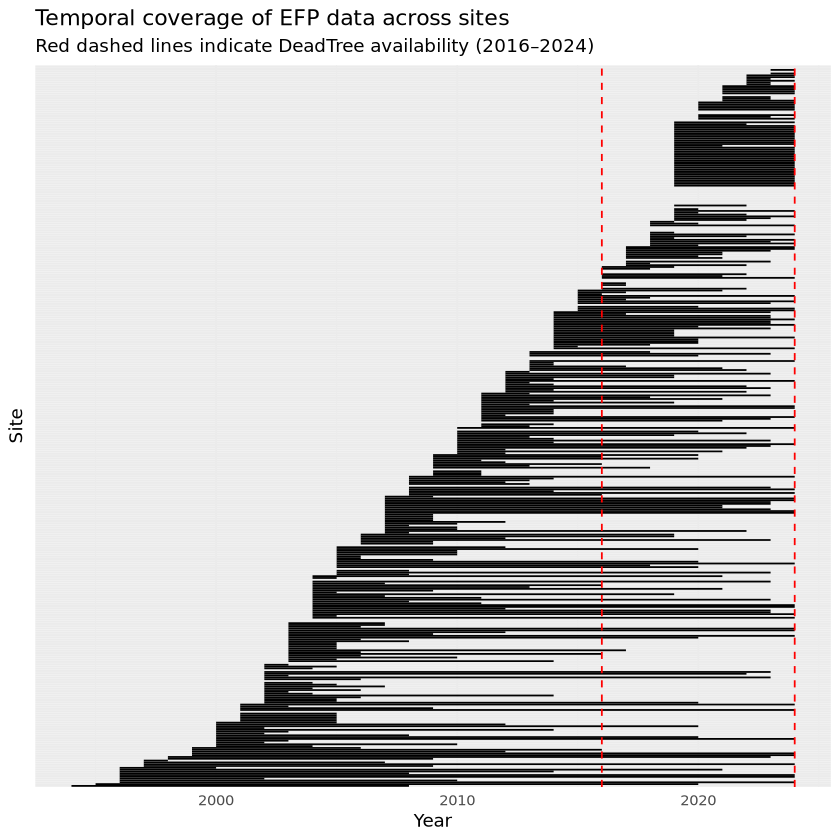

In [20]:
library(ggplot2)

ggplot(efp_all, aes(y = reorder(site_id, first_year))) +
  geom_segment(
    aes(x = first_year, xend = last_year, yend = site_id),
    linewidth = 0.5
  ) +
  geom_vline(xintercept = c(2016, 2024), linetype = "dashed", color = "red") +
  labs(
    x = "Year",
    y = "Site",
    title = "Temporal coverage of EFP data across sites",
    subtitle = "Red dashed lines indicate DeadTree availability (2016–2024)"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank()
  )

In [25]:

library(dplyr)

efp_2016_2024 <- efp_per_year %>%
  filter(first_year <= 2016, last_year >= 2024)

n_sites_2016_2024 <- nrow(efp_2016_2024)

n_sites_2016_2024



[1] 40

In [22]:
efp_2016_2024 %>% arrange(site_id)

site_id,n_years,first_year,last_year
<chr>,<dbl>,<dbl>,<dbl>
BE-Bra,23,1999,2024
BE-Dor,7,2014,2024
BE-Lon,18,2004,2024
BE-Vie,28,1996,2024
CZ-BK1,20,2004,2024
CZ-Lnz,9,2015,2024
DE-HoH,8,2015,2024
DE-Hzd,13,2010,2024
DE-RuS,9,2011,2024


In [24]:
common_sites <- intersect(efp_all$site_id, deadtree_500m$site_id)

length(common_sites)

[1] 348

In [25]:
### number of sites which fully cover the period 2016-2024
efp_2016_2024 %>%
  filter(site_id %in% common_sites) %>%
  nrow()

[1] 17

In [1]:
library(readr)
library(dplyr)
library(stringr)
library(purrr)
library(tidyr)
library(ggplot2)

efp_dir <- "efp_site_year_results"
efp_files <- list.files(efp_dir, pattern = "_EFP_yearly\\.csv$", full.names = TRUE)

get_site_id <- function(path) str_replace(basename(path), "_EFP_yearly\\.csv$", "")

# Read only what we need: site_id + year column
# If you already know the year column name is "year", keep it.
# Otherwise this auto-detect tries common names.
detect_year_col <- function(df) {
  candidates <- c("year","Year","YEAR","yyyy","YYYY","yr","YR")
  hit <- candidates[candidates %in% names(df)][1]
  if (is.na(hit)) NA_character_ else hit
}

efp_site_year <- map_dfr(efp_files, function(f) {
  df <- suppressMessages(read_csv(f, show_col_types = FALSE))
  yc <- detect_year_col(df)
  if (is.na(yc)) stop(paste("No year column found in:", basename(f)))

  tibble(
    site_id = get_site_id(f),
    year = as.integer(df[[yc]])
  ) %>%
    filter(!is.na(year)) %>%
    distinct()
})

# Optional: focus on 2016–2024 (matches your deadtree window)
years_focus <- 2016:2024
efp_site_year_focus <- efp_site_year %>%
  filter(year %in% years_focus)

# To include "missing" years as blanks in the heatmap, make a complete grid
heat_df <- expand_grid(
  site_id = sort(unique(efp_site_year_focus$site_id)),
  year = years_focus
) %>%
  left_join(efp_site_year_focus %>% mutate(has_data = 1L),
            by = c("site_id","year")) %>%
  mutate(has_data = ifelse(is.na(has_data), 0L, has_data))




Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
print(efp_site_year_focus)

# A tibble: 1,245 × 2
   site_id  year
   <chr>   <int>
 1 AT-Neu   2016
 2 AT-Neu   2017
 3 AT-Neu   2018
 4 AT-Neu   2019
 5 AT-Neu   2020
 6 AU-Boy   2017
 7 AU-Boy   2018
 8 AU-Boy   2019
 9 AU-Boy   2020
10 AU-Boy   2021
# ℹ 1,235 more rows


In [3]:
length(unique(efp_site_year_focus$site_id))

[1] 253

In [4]:
library(dplyr)

years_per_site <- efp_site_year_focus %>%
  distinct(site_id, year) %>%        # safety: ensure uniqueness
  count(site_id, name = "n_years")

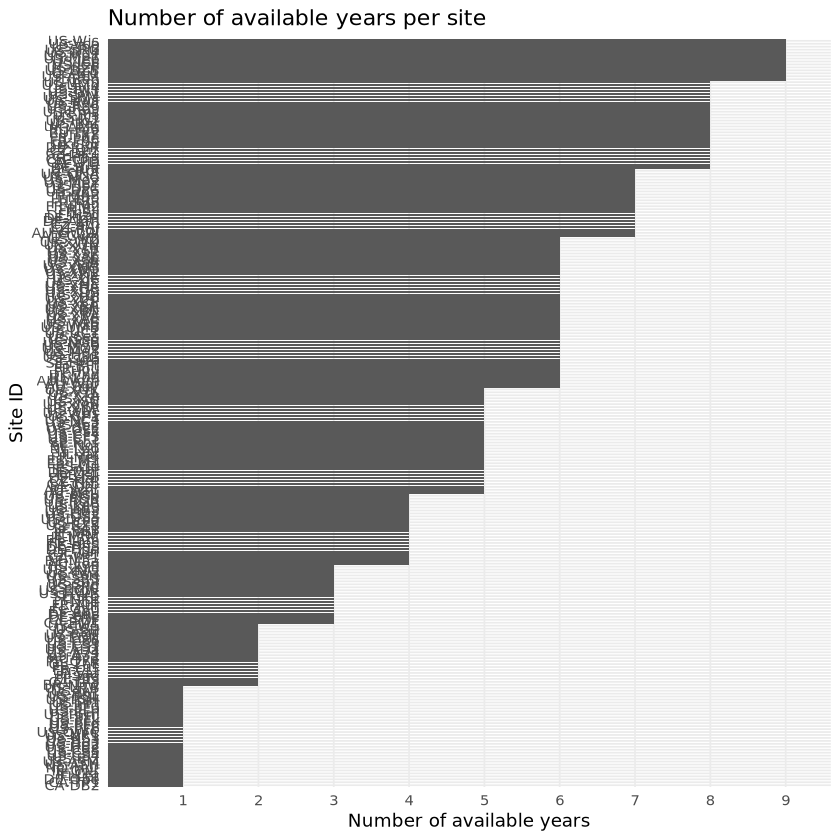

In [5]:
library(ggplot2)

ggplot(years_per_site, aes(x = reorder(site_id, n_years), y = as.factor(n_years))) +
  geom_col() +
  coord_flip() +
  labs(
    x = "Site ID",
    y = "Number of available years",
    title = "Number of available years per site"
  ) +
  theme_minimal()

In [1]:
ggplot(years_per_site, aes(x = n_years)) +
  geom_histogram(binwidth = 1, boundary = 0) +
  labs(
    x = "Number of years per site",
    y = "Number of sites",
    title = "Distribution of temporal coverage across sites"
  ) +
  theme_minimal()

ERROR: Error in ggplot(years_per_site, aes(x = n_years)): could not find function "ggplot"


In [7]:
library(dplyr)

site_year_index <- efp_site_year_focus %>%
  distinct(site_id, year) %>%
  filter(year >= 2016, year <= 2024)

sites_keep <- site_year_index %>% distinct(site_id)

In [8]:
print(sites_keep)

# A tibble: 253 × 1
   site_id
   <chr>  
 1 AT-Neu 
 2 AU-Boy 
 3 AU-Cum 
 4 AU-GWW 
 5 AU-Lon 
 6 AU-Rgf 
 7 AU-War 
 8 AU-Whr 
 9 AU-Wom 
10 BE-Bra 
# ℹ 243 more rows


In [7]:
library(readr)
library(purrr)
library(stringr)


Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose




In [ ]:


efp_dir <- "efp_site_year_results"

# list all EFP yearly files
efp_files <- list.files(efp_dir, pattern = "_EFP_yearly\\.csv$", full.names = TRUE)

# helper: get site_id from filename "BE-Bra_EFP_yearly.csv" -> "BE-Bra"
get_site <- function(path) str_remove(basename(path), "_EFP_yearly\\.csv$")

# keep only files that are in your 253-site set
efp_files_keep <- efp_files[get_site(efp_files) %in% sites_keep$site_id]

# read and bind
efp_all <- map_dfr(efp_files_keep, ~ read_csv(.x, show_col_types = FALSE) %>%
                     mutate(site_id = get_site(.x)))

In [10]:
write_csv(efp_all, "253sites_4_deadtree.csv")


In [11]:
print(efp_all)

# A tibble: 2,216 × 23
    uWUE ETmax precipAvail Gavail  GSmax CO2avail    G1    EF EFampl GPPsat
   <dbl> <dbl> <chr>       <chr>   <dbl> <chr>    <dbl> <dbl>  <dbl>  <dbl>
 1  3.97 0.342 yes         yes    0.0252 yes       2.62 0.872  0.238   38.3
 2  4.51 0.287 yes         yes    0.0116 yes       1.02 0.892  0.292   34.3
 3  3.81 0.281 yes         yes    0.0235 yes       2.83 0.891  0.242   38.7
 4  3.95 0.291 yes         yes    0.0186 yes       2.31 0.819  0.294   37.9
 5  3.73 0.302 yes         yes    0.0245 yes       2.31 0.846  0.261   37.7
 6  4.94 0.266 yes         yes    0.0141 yes       1.77 0.849  0.255   40.9
 7  4.97 0.283 yes         yes    0.0191 yes       1.70 0.811  0.267   46.4
 8  5.24 0.267 yes         yes    0.0173 yes       1.47 0.805  0.286   46.5
 9  4.44 0.273 yes         yes    0.0152 yes       1.95 0.797  0.245   40.7
10  5.52 0.278 yes         yes    0.0160 yes       1.78 0.810  0.266   47.4
# ℹ 2,206 more rows
# ℹ 13 more variables: NEPmax <dbl>, Rb <dbl>

In [12]:
str(efp_all)

tibble [2,216 × 23] (S3: tbl_df/tbl/data.frame)
 $ uWUE         : num [1:2216] 3.97 4.51 3.81 3.95 3.73 ...
 $ ETmax        : num [1:2216] 0.342 0.287 0.281 0.291 0.302 ...
 $ precipAvail  : chr [1:2216] "yes" "yes" "yes" "yes" ...
 $ Gavail       : chr [1:2216] "yes" "yes" "yes" "yes" ...
 $ GSmax        : num [1:2216] 0.0252 0.0116 0.0235 0.0186 0.0245 ...
 $ CO2avail     : chr [1:2216] "yes" "yes" "yes" "yes" ...
 $ G1           : num [1:2216] 2.62 1.02 2.83 2.31 2.31 ...
 $ EF           : num [1:2216] 0.872 0.892 0.891 0.819 0.846 ...
 $ EFampl       : num [1:2216] 0.238 0.292 0.242 0.294 0.261 ...
 $ GPPsat       : num [1:2216] 38.3 34.3 38.7 37.9 37.7 ...
 $ NEPmax       : num [1:2216] 28.9 25.9 28.4 28.5 30.3 ...
 $ Rb           : num [1:2216] NA NA NA NA NA NA NA NA NA NA ...
 $ Rbmax        : num [1:2216] NA NA NA NA NA NA NA NA NA NA ...
 $ aCUE         : num [1:2216] NA NA NA NA NA NA NA NA NA NA ...
 $ TZ           : num [1:2216] 1 1 1 1 1 1 1 1 1 1 ...
 $ nyears       : nu

In [13]:
efp_2016_2024 <- efp_all %>%
  # make sure year exists and is numeric/int
  mutate(year = as.integer(year)) %>%
  filter(year >= 2016, year <= 2024) %>%
  semi_join(site_year_index, by = c("site_id", "year"))

In [14]:
str(efp_2016_2024)

tibble [1,245 × 23] (S3: tbl_df/tbl/data.frame)
 $ uWUE         : num [1:1245] 4.34 5.28 5.27 5.43 6.93 ...
 $ ETmax        : num [1:1245] 0.272 0.258 0.241 0.283 0.197 ...
 $ precipAvail  : chr [1:1245] "yes" "yes" "yes" "yes" ...
 $ Gavail       : chr [1:1245] "yes" "yes" "yes" "yes" ...
 $ GSmax        : num [1:1245] 0.015 0.01141 0.01031 0.01135 0.00694 ...
 $ CO2avail     : chr [1:1245] "yes" "yes" "yes" "yes" ...
 $ G1           : num [1:1245] 1.469 0.878 0.913 0.62 0.216 ...
 $ EF           : num [1:1245] 0.836 0.812 0.839 0.791 0.733 ...
 $ EFampl       : num [1:1245] 0.266 0.254 0.326 0.341 0.317 ...
 $ GPPsat       : num [1:1245] 41.4 45.6 38.9 42.7 43.8 ...
 $ NEPmax       : num [1:1245] 27 27 27.1 30.2 26.7 ...
 $ Rb           : num [1:1245] NA NA NA NA NA NA NA NA NA NA ...
 $ Rbmax        : num [1:1245] NA NA NA NA NA NA NA NA NA NA ...
 $ aCUE         : num [1:1245] NA NA NA NA NA NA NA NA NA NA ...
 $ TZ           : num [1:1245] 1 1 1 1 1 8 8 8 8 8 ...
 $ nyears       :

In [15]:
length(unique(efp_2016_2024$site_id))

[1] 253

In [10]:
dt_path <- "derived_tables/deadtree_deadwood_forest_siteyear_mean_500m.csv"

deadtree_500m <- read_csv(dt_path, show_col_types = FALSE)


In [11]:
str(deadtree_500m)

spc_tbl_ [3,245 × 4] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ site_id          : chr [1:3245] "AR-SLu" "AR-SLu" "AR-SLu" "AR-SLu" ...
 $ year             : num [1:3245] 2016 2017 2018 2019 2020 ...
 $ deadwood_mean_1km: num [1:3245] 0.005006 0.007925 0.001051 0.003461 0.000876 ...
 $ forest_mean_1km  : num [1:3245] 0.00288 0.12393 0.09472 0.04841 0.04944 ...
 - attr(*, "spec")=
  .. cols(
  ..   site_id = col_character(),
  ..   year = col_double(),
  ..   deadwood_mean_1km = col_double(),
  ..   forest_mean_1km = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


In [22]:
final_df <- efp_2016_2024 %>%
  left_join(deadtree_500m, by = c("site_id", "year"))

In [23]:
str(final_df)

tibble [1,245 × 25] (S3: tbl_df/tbl/data.frame)
 $ uWUE             : num [1:1245] 4.34 5.28 5.27 5.43 6.93 ...
 $ ETmax            : num [1:1245] 0.272 0.258 0.241 0.283 0.197 ...
 $ precipAvail      : chr [1:1245] "yes" "yes" "yes" "yes" ...
 $ Gavail           : chr [1:1245] "yes" "yes" "yes" "yes" ...
 $ GSmax            : num [1:1245] 0.015 0.01141 0.01031 0.01135 0.00694 ...
 $ CO2avail         : chr [1:1245] "yes" "yes" "yes" "yes" ...
 $ G1               : num [1:1245] 1.469 0.878 0.913 0.62 0.216 ...
 $ EF               : num [1:1245] 0.836 0.812 0.839 0.791 0.733 ...
 $ EFampl           : num [1:1245] 0.266 0.254 0.326 0.341 0.317 ...
 $ GPPsat           : num [1:1245] 41.4 45.6 38.9 42.7 43.8 ...
 $ NEPmax           : num [1:1245] 27 27 27.1 30.2 26.7 ...
 $ Rb               : num [1:1245] NA NA NA NA NA NA NA NA NA NA ...
 $ Rbmax            : num [1:1245] NA NA NA NA NA NA NA NA NA NA ...
 $ aCUE             : num [1:1245] NA NA NA NA NA NA NA NA NA NA ...
 $ TZ           

In [24]:
write_csv(final_df, "deadtree_efp2016_2024.csv")

In [3]:
library(data.table)

In [4]:
final_df<-fread("deadtree_efp2016_2024.csv")

In [5]:
colSums(is.na(final_df[, c("GPPsat","NEPmax","uWUE","ETmax",
                           "deadwood_mean_1km","forest_mean_1km")]))

GPPsat            NEPmax              uWUE             ETmax 
                0                 0                 0                 0 
deadwood_mean_1km   forest_mean_1km 
              282               282

In [12]:
n_distinct(final_df$site_id)            # should be 253 (or less if some EFP files missing)
range(final_df$year, na.rm = TRUE)      # should be 2016–2024
final_df %>% count(site_id) %>% summary()  # number of years per site in final dataset

[1] 253

[1] 2016 2024

   site_id                n        
 Length:253         Min.   :1.000  
 Class :character   1st Qu.:3.000  
 Mode  :character   Median :5.000  
                    Mean   :4.921  
                    3rd Qu.:7.000  
                    Max.   :9.000  

In [26]:
unique(final_df$IGBP)

[1] "GRA" "EBF" "SAV" "CRO" "ENF" "CSH" "MF"  "WSA" "DBF" "WET" "OSH" "DNF"
[13] "CVM" "SNO" "BSV"

In [28]:
forest_df <- final_df %>%
  filter(IGBP %in% c("ENF","EBF","DBF","MF","DNF"))

In [31]:
length(unique(forest_df$site_id))

[1] 101

Warning message:
“Removed 167 rows containing missing values or values outside the scale range
(`geom_point()`).”


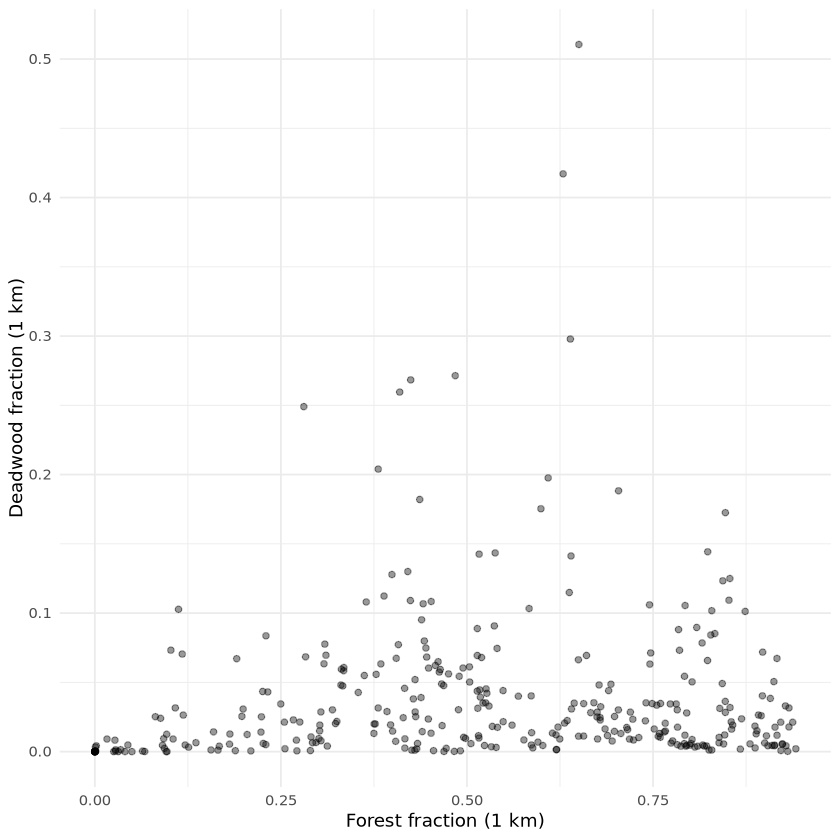

In [32]:
ggplot(forest_df, aes(x = forest_mean_1km, y = deadwood_mean_1km)) +
  geom_point(alpha = 0.4) +
  theme_minimal() +
  labs(x = "Forest fraction (1 km)", y = "Deadwood fraction (1 km)")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 167 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 167 rows containing missing values or values outside the scale range
(`geom_point()`).”


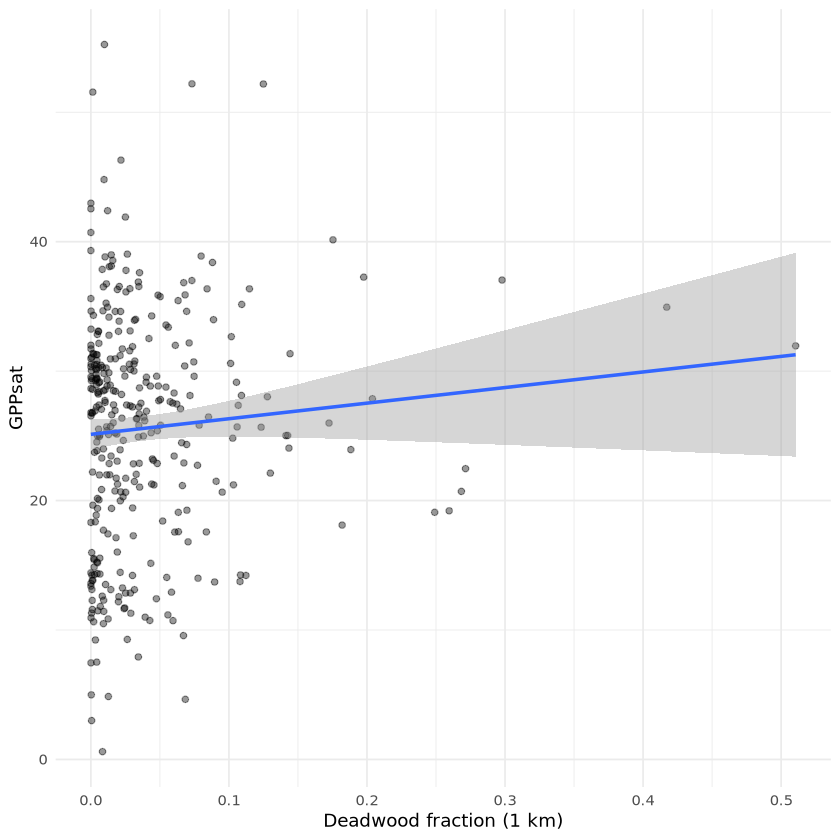

In [33]:
ggplot(forest_df, aes(x = deadwood_mean_1km, y = GPPsat)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = TRUE) +
  theme_minimal() +
  labs(x = "Deadwood fraction (1 km)", y = "GPPsat")

In [34]:
site_means <- forest_df %>%
  group_by(site_id) %>%
  summarise(
    deadwood = mean(deadwood_mean_1km, na.rm = TRUE),
    forest   = mean(forest_mean_1km, na.rm = TRUE),
    GPPsat   = mean(GPPsat, na.rm = TRUE),
    NEPmax   = mean(NEPmax, na.rm = TRUE),
    uWUE     = mean(uWUE, na.rm = TRUE),
    lat      = first(LOCATION_LAT),
    IGBP     = first(IGBP),
    n_years  = n()
  )

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 30 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_point()`).”


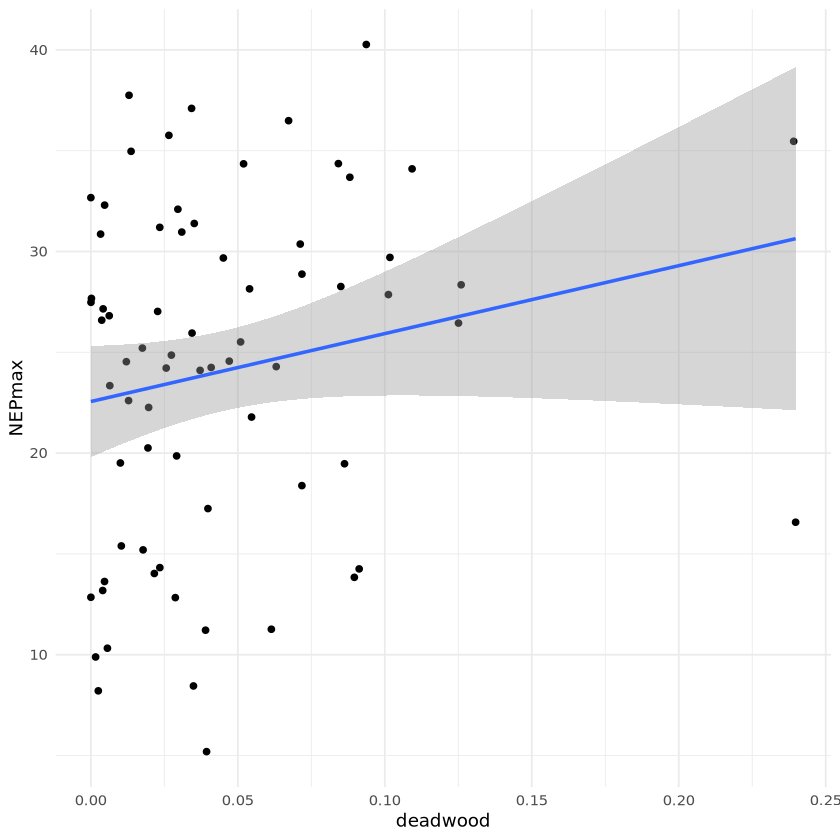

In [35]:
ggplot(site_means, aes(x = deadwood, y = NEPmax)) +
  geom_point() +
  geom_smooth(method = "lm") +
  theme_minimal()

In [36]:
library(lme4)

m_gpp <- lmer(GPPsat ~ 
                deadwood_mean_1km +
                forest_mean_1km +
                LOCATION_LAT +
                scale(year) +
                (1 | site_id),
              data = forest_df,
              na.action = na.exclude)

summary(m_gpp)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




Linear mixed model fit by REML ['lmerMod']
Formula: GPPsat ~ deadwood_mean_1km + forest_mean_1km + LOCATION_LAT +  
    scale(year) + (1 | site_id)
   Data: forest_df

REML criterion at convergence: 2135.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7134 -0.4198  0.0089  0.4153  4.9707 

Random effects:
 Groups   Name        Variance Std.Dev.
 site_id  (Intercept) 57.90    7.609   
 Residual             16.79    4.098   
Number of obs: 345, groups:  site_id, 71

Fixed effects:
                  Estimate Std. Error t value
(Intercept)       22.19123    2.06378  10.753
deadwood_mean_1km -9.67643    6.18507  -1.564
forest_mean_1km    8.01125    1.94146   4.126
LOCATION_LAT      -0.00634    0.04089  -0.155
scale(year)       -0.04908    0.32037  -0.153

Correlation of Fixed Effects:
            (Intr) ddw__1 frs__1 LOCATI
ddwd_mn_1km -0.103                     
frst_mn_1km -0.422 -0.129              
LOCATION_LA -0.731  0.048 -0.089       
scale(year)  0.136  0.113 -0.29

In [37]:
cor(forest_df$deadwood_mean_1km, forest_df$forest_mean_1km, use = "complete.obs")

[1] 0.09654109

In [38]:
forest_df <- forest_df %>%
  mutate(deadwood_sc = scale(deadwood_mean_1km),
         forest_sc   = scale(forest_mean_1km),
         lat_sc      = scale(LOCATION_LAT))

In [39]:
m_gpp2 <- lmer(GPPsat ~ 
                 deadwood_sc +
                 forest_sc +
                 lat_sc +
                 scale(year) +
                 (1 | site_id),
               data = forest_df)

summary(m_gpp2)

Linear mixed model fit by REML ['lmerMod']
Formula: GPPsat ~ deadwood_sc + forest_sc + lat_sc + scale(year) + (1 |  
    site_id)
   Data: forest_df

REML criterion at convergence: 2137.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7134 -0.4198  0.0089  0.4153  4.9707 

Random effects:
 Groups   Name        Variance Std.Dev.
 site_id  (Intercept) 57.90    7.609   
 Residual             16.79    4.098   
Number of obs: 345, groups:  site_id, 71

Fixed effects:
            Estimate Std. Error t value
(Intercept) 25.71917    0.94833  27.120
deadwood_sc -0.55647    0.35569  -1.564
forest_sc    2.18903    0.53049   4.126
lat_sc      -0.14047    0.90591  -0.155
scale(year) -0.04908    0.32037  -0.153

Correlation of Fixed Effects:
            (Intr) ddwd_s frst_s lat_sc
deadwood_sc -0.023                     
forest_sc   -0.046 -0.129              
lat_sc       0.095  0.048 -0.089       
scale(year) -0.009  0.113 -0.293 -0.013

In [40]:
m_gpp_int <- lmer(GPPsat ~ 
                    deadwood_sc * forest_sc +
                    lat_sc +
                    scale(year) +
                    (1 | site_id),
                  data = forest_df)

summary(m_gpp_int)

Linear mixed model fit by REML ['lmerMod']
Formula: GPPsat ~ deadwood_sc * forest_sc + lat_sc + scale(year) + (1 |  
    site_id)
   Data: forest_df

REML criterion at convergence: 2137

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7038 -0.4177  0.0070  0.4161  4.9602 

Random effects:
 Groups   Name        Variance Std.Dev.
 site_id  (Intercept) 57.95    7.613   
 Residual             16.85    4.105   
Number of obs: 345, groups:  site_id, 71

Fixed effects:
                      Estimate Std. Error t value
(Intercept)           25.71355    0.95350  26.968
deadwood_sc           -0.56345    0.37771  -1.492
forest_sc              2.19902    0.55319   3.975
lat_sc                -0.14037    0.90641  -0.155
scale(year)           -0.05207    0.32449  -0.160
deadwood_sc:forest_sc  0.03457    0.59672   0.058

Correlation of Fixed Effects:
            (Intr) ddwd_s frst_s lat_sc scl(y)
deadwood_sc  0.011                            
forest_sc   -0.071 -0.210                  

In [13]:
library(ggeffects)

pred <- ggpredict(m_gpp2, terms = "deadwood_sc")

plot(pred) +
  labs(x = "Deadwood (scaled)", y = "Predicted GPPsat") +
  theme_minimal()

ERROR: Error: object 'm_gpp2' not found


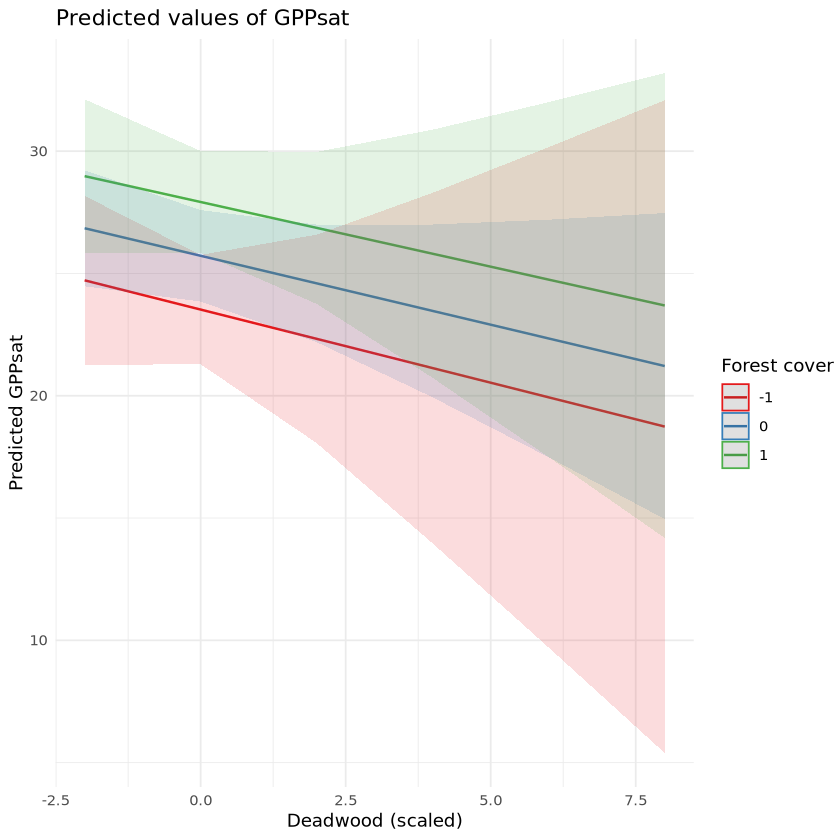

In [44]:
pred2 <- ggpredict(m_gpp_int, terms = c("deadwood_sc", "forest_sc [-1,0,1]"))

plot(pred2) +
  labs(x = "Deadwood (scaled)", y = "Predicted GPPsat", color = "Forest cover") +
  theme_minimal()

In [45]:
site_means <- forest_df %>%
  group_by(site_id) %>%
  summarise(
    deadwood = mean(deadwood_mean_1km, na.rm = TRUE),
    forest   = mean(forest_mean_1km, na.rm = TRUE),
    GPPsat   = mean(GPPsat, na.rm = TRUE),
    NEPmax   = mean(NEPmax, na.rm = TRUE),
    uWUE     = mean(uWUE, na.rm = TRUE),
    lat      = first(LOCATION_LAT)
  )

lm(GPPsat ~ deadwood + forest + lat, data = site_means) %>% summary()


Call:
lm(formula = GPPsat ~ deadwood + forest + lat, data = site_means)

Residuals:
     Min       1Q   Median       3Q      Max 
-16.4702  -3.9604  -0.0146   3.7140  29.5075 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 18.02392    2.60687   6.914 2.16e-09 ***
deadwood    15.77036   20.31048   0.776 0.440208    
forest      14.06119    3.84204   3.660 0.000498 ***
lat         -0.01369    0.04140  -0.331 0.741863    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.736 on 67 degrees of freedom
  (30 observations deleted due to missingness)
Multiple R-squared:  0.1962,	Adjusted R-squared:  0.1602 
F-statistic: 5.451 on 3 and 67 DF,  p-value: 0.002055


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP yearly data availability by site (2016–2024)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP yearly data availability by site (2016–2024)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP yearly data availability by site (2016–2024)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP yearly data availability by site (2016–2024)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP yearly data availability by site (2016–2024)' in 'mbcsToSbcs': dot substituted for <80>”

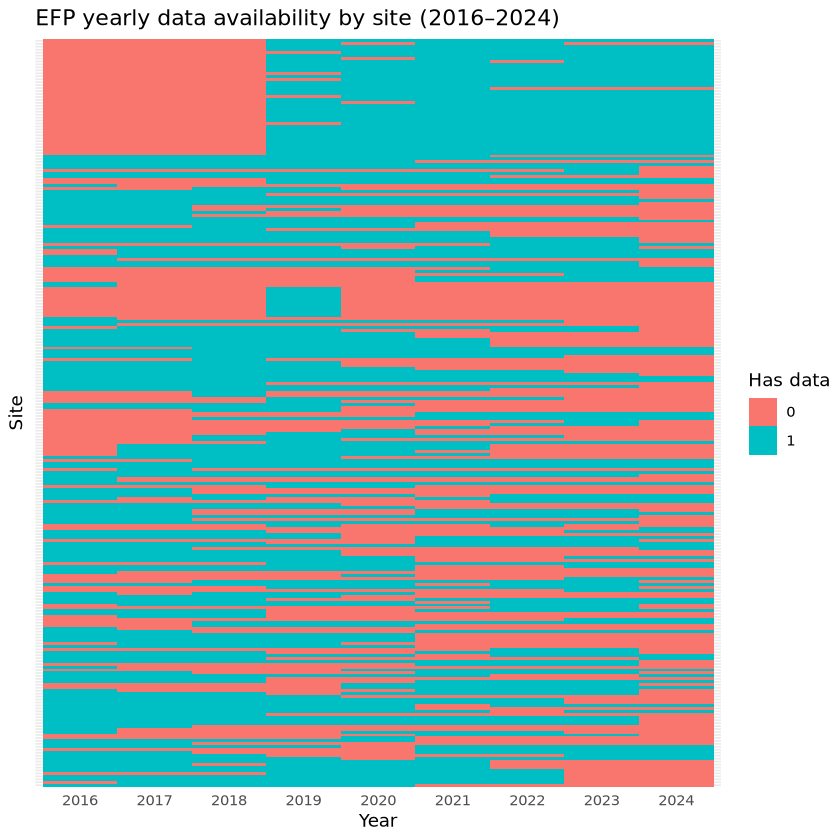

In [27]:
# Plot: heatmap (tile = available/not)
ggplot(heat_df, aes(x = as.character(year), y = site_id, fill = factor(has_data))) +
  geom_tile() +
  labs(
    title = "EFP yearly data availability by site (2016–2024)",
    x = "Year", y = "Site",
    fill = "Has data"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank()
  )

In [21]:
### Let's have EFP per site for example GPPsat, NEPmax, Emax, WUEmax, etc.
### standing deadwood, VPD, Percipitation, temperature, sw radiation,... as predictors.

### first read the EFP table   
library(readr)
efp_all <- read_csv("efp_per_site/EFP_per_sitesV0Dec.csv", show_col_types = FALSE)


In [5]:
print(efp_all)

# A tibble: 348 × 23
   SITE_ID siteID   uWUE  ETmax precipAvail Gavail   GSmax CO2avail     G1    EF
   <chr>   <chr>   <dbl>  <dbl> <chr>       <chr>    <dbl> <chr>     <dbl> <dbl>
 1 AR-SLu  AR-SLu 14.6   0.119  yes         yes    3.10e-3 yes      -0.495 0.170
 2 AR-Vir  AR-Vir  4.00  0.294  yes         yes    7.29e-4 yes      -0.828 0.777
 3 AT-Neu  AT-Neu  4.74  0.273  yes         yes    1.56e-2 yes       1.45  0.823
 4 AU-Boy  AU-Boy  1.16  0.107  yes         yes    1.77e-2 yes       1.90  0.219
 5 AU-Emr  AU-Emr  2.69  0.126  yes         yes    2.82e-3 yes       1.48  0.292
 6 AU-Gin  AU-Gin  3.20  0.137  yes         yes    4.29e-3 yes       2.24  0.301
 7 AU-GWW  AU-GWW  1.04  0.0785 yes         yes    7.89e-3 yes       1.63  0.143
 8 AU-Lon  AU-Lon  1.07  0.181  yes         yes    1.61e-2 yes       2.00  0.496
 9 AU-Rgf  AU-Rgf  0.623 0.164  yes         yes    2.62e-2 yes       2.03  0.581
10 AU-Rig  AU-Rig  2.36  0.191  yes         yes    5.97e-3 yes       2.45  0.517
# ℹ 338

In [6]:
str(efp_all)


spc_tbl_ [348 × 23] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ SITE_ID      : chr [1:348] "AR-SLu" "AR-Vir" "AT-Neu" "AU-Boy" ...
 $ siteID       : chr [1:348] "AR-SLu" "AR-Vir" "AT-Neu" "AU-Boy" ...
 $ uWUE         : num [1:348] 14.64 4 4.74 1.16 2.69 ...
 $ ETmax        : num [1:348] 0.119 0.294 0.273 0.107 0.126 ...
 $ precipAvail  : chr [1:348] "yes" "yes" "yes" "yes" ...
 $ Gavail       : chr [1:348] "yes" "yes" "yes" "yes" ...
 $ GSmax        : num [1:348] 0.003097 0.000729 0.015573 0.017682 0.002823 ...
 $ CO2avail     : chr [1:348] "yes" "yes" "yes" "yes" ...
 $ G1           : num [1:348] -0.495 -0.828 1.448 1.898 1.483 ...
 $ EF           : num [1:348] 0.17 0.777 0.823 0.219 0.292 ...
 $ EFampl       : num [1:348] 0.203 0.314 0.283 0.147 0.223 ...
 $ GPPsat       : num [1:348] 28.2 42.4 42.8 13.4 12 ...
 $ NEPmax       : num [1:348] 29.8 31.6 29.5 14.7 16.1 ...
 $ Rb           : num [1:348] NA NA 15.4 NA NA ...
 $ Rbmax        : num [1:348] NA NA 21.8 NA NA ...
 $ aCUE        

In [18]:
### read the deadwood data
library(data.table)
final_df <- fread("derived_tables/EFP_climate_deadwood_trait_500m_yearly.csv")

In [19]:
print(final_df)

      SITE_ID  year      uWUE     ETmax precipAvail Gavail        GSmax
       <char> <int>     <num>     <num>      <char> <char>        <num>
   1:  AR-SLu  2009  7.675812 0.2352526         yes    yes 8.697826e-03
   2:  AR-SLu  2010 16.240289 0.1064140         yes    yes 2.667232e-03
   3:  AR-SLu  2011 10.692879 0.1329507         yes    yes 3.875241e-03
   4:  AR-Vir  2010  4.074392 0.3243859         yes    yes 7.750829e-04
   5:  AR-Vir  2011  3.754120 0.2637845         yes    yes 7.116720e-04
  ---                                                                  
2307:  ZA-Kru  2004  3.999096 0.4011044         yes    yes 2.429775e-07
2308:  ZA-Kru  2005  2.722959 0.4486521         yes    yes 6.231033e-07
2309:  ZM-Mon  2007  3.700569 0.2140455         yes    yes 6.424542e-03
2310:  ZM-Mon  2008  3.094234 0.2244055         yes    yes 8.911256e-03
2311:  ZM-Mon  2009  2.833322 0.2439872         yes    yes 1.051414e-02
      CO2avail         G1        EF    EFampl   GPPsat   NEPmax 

In [20]:
names(final_df)

[1] "SITE_ID"               "year"                  "uWUE"                 
 [4] "ETmax"                 "precipAvail"           "Gavail"               
 [7] "GSmax"                 "CO2avail"              "G1"                   
[10] "EF"                    "EFampl"                "GPPsat"               
[13] "NEPmax"                "Rb"                    "Rbmax"                
[16] "aCUE"                  "TZ"                    "nyears"               
[19] "LOCATION_LAT"          "LOCATION_LONG"         "LOCATION_ELEV"        
[22] "IGBP"                  "P_mm"                  "Tair_mean_C"          
[25] "SWin_mean_Wm2"         "VPD_GS_hPa"            "deadwood_mean_500m"   
[28] "forest_mean_500m"      "Leaf C"                "Leaf N (mass)"        
[31] "Leaf width"            "Leaf C/N ratio"        "Leaf P"               
[34] "Stem conduit density"  "Stem conduit diameter" "Leaf area (3112)"     
[37] "Leaf area"             "Leaf area (3114)"      "SLA"                  
[40] "SSD"                   "Leaf thickness"        "Leaf N (area)"        
[43] "Leaf dry mass"         "Rooting depth"         "Leaf delta 15N"

In [21]:
clim_vars <- c("P_mm","Tair_mean_C","SWin_mean_Wm2","VPD_GS_hPa")

# add anomalies to the FULL table
for (v in clim_vars) {
  final_df[, paste0(v, "_anom") := get(v) - mean(get(v), na.rm = TRUE), by = SITE_ID]
}

# keep a separate climate-only table (optional)
climate_only <- final_df[, c("SITE_ID","year", clim_vars, paste0(clim_vars, "_anom")), with = FALSE]



In [22]:
library(data.table)

clim_anoms <- paste0(clim_vars, "_anom")

trait_vars <- c("Rooting depth","Leaf N (mass)","Leaf N (area)","SLA","Stem conduit density")
struct_vars <- c("deadwood_mean_500m","forest_mean_500m")

efps <- c("GPPsat","NEPmax","ETmax","uWUE")

In [23]:
library(data.table)

setnames(final_df,
         old = c("Rooting depth","Leaf N (mass)","Leaf N (area)","Stem conduit density"),
         new = c("Rooting_depth","LeafN_mass","LeafN_area","Stem_conduit_density"),
         skip_absent = TRUE)

trait_vars <- c("Rooting_depth","LeafN_mass","LeafN_area","SLA","Stem_conduit_density")

In [24]:
final_df <- final_df[order(SITE_ID, year)]
final_df[, deadwood_3yr := frollsum(fifelse(is.na(deadwood_mean_500m), 0, deadwood_mean_500m),
                                    n = 3, align = "right"), by = SITE_ID]

Subset the data without losing it

In [25]:
model_cols <- c("SITE_ID","year", efps, clim_anoms, trait_vars, "deadwood_3yr", "forest_mean_500m")

missing <- setdiff(model_cols, names(final_df))
if (length(missing)) message("Missing: ", paste(missing, collapse=", "))

dt <- final_df[, intersect(model_cols, names(final_df)), with = FALSE]

quick check

In [26]:
names(dt)
summary(dt$GPPsat)

[1] "SITE_ID"              "year"                 "GPPsat"              
 [4] "NEPmax"               "ETmax"                "uWUE"                
 [7] "P_mm_anom"            "Tair_mean_C_anom"     "SWin_mean_Wm2_anom"  
[10] "VPD_GS_hPa_anom"      "Rooting_depth"        "LeafN_mass"          
[13] "LeafN_area"           "SLA"                  "Stem_conduit_density"
[16] "deadwood_3yr"         "forest_mean_500m"

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
  -0.006   12.621   21.880   26.704   30.558 9999.000        4 

In [27]:
library(data.table)

# set common sentinel codes to NA for all numeric columns
sentinels <- c(9999, -9999, 6999, -6999, 999, -999)

num_cols <- names(dt)[sapply(dt, is.numeric)]

for (c in num_cols) {
  dt[get(c) %in% sentinels, (c) := NA_real_]
}

# also remove impossible values (optional but helpful)
dt[GPPsat < -1 | GPPsat > 200, GPPsat := NA_real_]
dt[NEPmax < -200 | NEPmax > 200, NEPmax := NA_real_]
dt[ETmax  < 0 | ETmax > 50, ETmax := NA_real_]
dt[uWUE   < -50 | uWUE > 100, uWUE := NA_real_]

In [28]:
summary(dt$GPPsat)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
-0.00616 12.61957 21.87127 22.37933 30.55574 73.20970        5 

In [34]:
fwrite(dt, "derived_tables/final_model_table_clean.csv")

In [6]:
library(data.table)
dt <- fread("derived_tables/final_model_table_clean.csv")

In [7]:
View(dt)

SITE_ID,year,GPPsat,NEPmax,ETmax,uWUE,P_mm_anom,Tair_mean_C_anom,SWin_mean_Wm2_anom,VPD_GS_hPa_anom,Rooting_depth,LeafN_mass,LeafN_area,SLA,Stem_conduit_density,deadwood_3yr,forest_mean_500m
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR-SLu,2009,25.251036,33.46052,0.23525256,7.6758122,-5.581333,NA,33.9295568,NA,0.6918347,22.42068,1.922857,9.927664,59.54188,NA,NA
AR-SLu,2010,28.225178,29.46826,0.10641401,16.2402893,-9.297333,0.000000000,-10.8593092,0.0000000,0.6918347,22.42068,1.922857,9.927664,59.54188,NA,NA
AR-SLu,2011,27.810574,29.24031,0.13295070,10.6928793,14.878667,NA,-23.0702476,NA,0.6918347,22.42068,1.922857,9.927664,59.54188,0.000000000,NA
AR-Vir,2010,42.463865,32.65211,0.32438591,4.0743924,231.340000,0.002790126,75.8161106,1.0913705,1.0653660,20.22492,1.432450,14.662185,32.99233,NA,NA
AR-Vir,2011,45.321191,31.42823,0.26378451,3.7541200,71.218000,-0.002790126,4.3129846,-1.0913705,1.0653660,20.22492,1.432450,14.662185,32.99233,NA,NA
AR-Vir,2012,36.414673,19.93968,0.26984531,4.3087226,-302.558000,NA,-80.1290953,NA,1.0653660,20.22492,1.432450,14.662185,32.99233,0.000000000,NA
AT-Neu,2002,38.305001,28.85910,0.34183833,3.9662324,216.801211,0.779965671,-1.2432221,3.3142638,0.3975373,23.53272,1.235504,20.128896,60.71813,NA,NA
AT-Neu,2003,34.322125,25.92760,0.28705336,4.5123157,-4.281789,0.152420522,8.1672920,11.5851052,0.3975373,23.53272,1.235504,20.128896,60.71813,NA,NA
AT-Neu,2004,38.681707,28.39840,0.28086398,3.8121818,18.546211,-0.443929339,-2.8309257,1.4338065,0.3975373,23.53272,1.235504,20.128896,60.71813,0.000000000,NA


In [1]:
library(data.table)
final_df <- fread("derived_tables/EFP_site_year_with_climate_deadwood_forest_500m_10Feb26.csv")

In [2]:
View(final_df)

site_id,year,uwue,etmax,precipavail,gavail,gsmax,co2avail,g1,ef,⋯,swin_mean_wm2,vpd_gs_hpa,p_mm,tair_mean_c,swin_mean_wm2.1,vpd_gs_hpa.1,forest_mean_pct_500m,deadwood_mean_pct_500m,forest_change_pp_from_baseline,forest_change_pp_yoy
<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR-SLu,2009,7.6758122,0.23525256,yes,yes,0.0086978262,yes,0.3358437,0.3127321,⋯,289.4884,-92853.247614,355.416,-9284.731548,289.4884,-92853.247614,NA,NA,NA,NA
AR-SLu,2010,16.2402893,0.10641401,yes,yes,0.0026672316,yes,-0.5497535,0.1492497,⋯,244.6995,122.504950,351.700,19.045888,244.6995,122.504950,NA,NA,NA,NA
AR-SLu,2011,10.6928793,0.13295070,yes,yes,0.0038752408,yes,-0.3088108,0.2533210,⋯,232.4886,-72565.125422,375.876,-7254.073823,232.4886,-72565.125422,NA,NA,NA,NA
AR-Vir,2010,4.0743924,0.32438591,yes,yes,0.0007750829,yes,-0.8520437,0.8271577,⋯,302.1818,90.723088,1664.070,21.384898,302.1818,90.723088,NA,NA,NA,NA
AR-Vir,2011,3.7541200,0.26378451,yes,yes,0.0007116720,yes,-0.7099170,0.7727688,⋯,230.6787,88.540347,1503.948,21.379318,230.6787,88.540347,NA,NA,NA,NA
AR-Vir,2012,4.3087226,0.26984531,yes,yes,0.0006417871,yes,-1.0401099,0.6727284,⋯,146.2366,-49958.515602,1130.172,-5072.032599,146.2366,-49958.515602,NA,NA,NA,NA
AT-Neu,2002,3.9662324,0.34183833,yes,yes,0.0252128596,yes,2.6204606,0.8719508,⋯,134.3473,38.204093,984.159,7.799844,134.3473,38.204093,NA,NA,NA,NA
AT-Neu,2003,4.5123157,0.28705336,yes,yes,0.0116077636,yes,1.0214599,0.8922966,⋯,143.7578,46.474935,763.076,7.172299,143.7578,46.474935,NA,NA,NA,NA
AT-Neu,2004,3.8121818,0.28086398,yes,yes,0.0235160029,yes,2.8260133,0.8910636,⋯,132.7596,36.323636,785.904,6.575949,132.7596,36.323636,NA,NA,NA,NA


In [12]:
fwrite(final_df, "derived_tables/EFP_site_year_with_climate_deadwood_forest_trait_500m_12Feb26.csv")

In [10]:
#### Add trait to the EPF and climate and deadwood data:
library(data.table)

# Make sure both objects exist and are data.tables
final_df <- as.data.table(final_df)
dt       <- as.data.table(dt)

# Extract one unique trait row per site
traits_site <- unique(
  dt[, .(
    SITE_ID,
    Rooting_depth,
    LeafN_area,
    SLA,
    Stem_conduit_density,
    LeafN_mass
  )]
)

# Rename key to match final_df
setnames(traits_site, "SITE_ID", "site_id")

# ------------------------------------------------
# Add trait columns using match (SAFE)
# ------------------------------------------------
m_idx <- match(final_df$site_id, traits_site$site_id)

final_df[, Rooting_depth        := traits_site$Rooting_depth[m_idx]]
final_df[, LeafN_area           := traits_site$LeafN_area[m_idx]]
final_df[, SLA                  := traits_site$SLA[m_idx]]
final_df[, Stem_conduit_density := traits_site$Stem_conduit_density[m_idx]]
final_df[, LeafN_mass           := traits_site$LeafN_mass[m_idx]]

In [11]:
View(final_df)

site_id,year,uwue,etmax,precipavail,gavail,gsmax,co2avail,g1,ef,⋯,vpd_gs_hpa,forest_mean_pct_500m,deadwood_mean_pct_500m,forest_change_pp_from_baseline,forest_change_pp_yoy,Rooting_depth,LeafN_area,SLA,Stem_conduit_density,LeafN_mass
<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR-SLu,2009,7.6758122,0.23525256,yes,yes,0.0086978262,yes,0.3358437,0.3127321,⋯,-92853.247614,NA,NA,NA,NA,0.6918347,1.922857,9.927664,59.54188,22.42068
AR-SLu,2010,16.2402893,0.10641401,yes,yes,0.0026672316,yes,-0.5497535,0.1492497,⋯,122.504950,NA,NA,NA,NA,0.6918347,1.922857,9.927664,59.54188,22.42068
AR-SLu,2011,10.6928793,0.13295070,yes,yes,0.0038752408,yes,-0.3088108,0.2533210,⋯,-72565.125422,NA,NA,NA,NA,0.6918347,1.922857,9.927664,59.54188,22.42068
AR-Vir,2010,4.0743924,0.32438591,yes,yes,0.0007750829,yes,-0.8520437,0.8271577,⋯,90.723088,NA,NA,NA,NA,1.0653660,1.432450,14.662185,32.99233,20.22492
AR-Vir,2011,3.7541200,0.26378451,yes,yes,0.0007116720,yes,-0.7099170,0.7727688,⋯,88.540347,NA,NA,NA,NA,1.0653660,1.432450,14.662185,32.99233,20.22492
AR-Vir,2012,4.3087226,0.26984531,yes,yes,0.0006417871,yes,-1.0401099,0.6727284,⋯,-49958.515602,NA,NA,NA,NA,1.0653660,1.432450,14.662185,32.99233,20.22492
AT-Neu,2002,3.9662324,0.34183833,yes,yes,0.0252128596,yes,2.6204606,0.8719508,⋯,38.204093,NA,NA,NA,NA,0.3975373,1.235504,20.128896,60.71813,23.53272
AT-Neu,2003,4.5123157,0.28705336,yes,yes,0.0116077636,yes,1.0214599,0.8922966,⋯,46.474935,NA,NA,NA,NA,0.3975373,1.235504,20.128896,60.71813,23.53272
AT-Neu,2004,3.8121818,0.28086398,yes,yes,0.0235160029,yes,2.8260133,0.8910636,⋯,36.323636,NA,NA,NA,NA,0.3975373,1.235504,20.128896,60.71813,23.53272


In [29]:
targets <- c("GPPsat","NEPmax","ETmax","uWUE")

pred_clim_trait <- c(
  "P_mm_anom","Tair_mean_C_anom","SWin_mean_Wm2_anom","VPD_GS_hPa_anom",
  "Rooting_depth","LeafN_mass","LeafN_area","SLA","Stem_conduit_density"
)

pred_full <- c(pred_clim_trait, "deadwood_3yr","forest_mean_500m")

 Site-blocked split on 2016–2024 (evaluation domain)

In [30]:
set.seed(42)

eval_years <- 2016:2024
eval_df <- dt[year %in% eval_years]

sites <- unique(eval_df$SITE_ID)
test_sites <- sample(sites, size = floor(0.2 * length(sites)))

test_df  <- eval_df[SITE_ID %in% test_sites]
train_df <- eval_df[!SITE_ID %in% test_sites]

Train & validate: RF baseline vs RF full (per target)

In [31]:
rmse <- function(y, yhat) sqrt(mean((y - yhat)^2, na.rm = TRUE))
r2   <- function(y, yhat) 1 - sum((y - yhat)^2, na.rm = TRUE) / sum((y - mean(y, na.rm=TRUE))^2, na.rm=TRUE)

In [35]:
library(ranger)

results <- list()
models  <- list()

for (y in targets) {

  # ---- baseline model: climate + traits (trained on train_df)
  d_train1 <- train_df[!is.na(get(y))]
  d_test   <- test_df[!is.na(get(y))]

  f1 <- as.formula(paste(y, "~", paste(pred_clim_trait, collapse = " + ")))

  m1 <- ranger(
    f1, data = d_train1[, c(y, pred_clim_trait), with = FALSE],
    num.trees = 500, importance = "permutation"
  )

  p1 <- predict(m1, data = d_test[, pred_clim_trait, with = FALSE])$predictions

  # ---- full model: add deadwood + forest (train only where available)
  d_train2 <- d_train1[!is.na(deadwood_3yr) & !is.na(forest_mean_500m)]
  f2 <- as.formula(paste(y, "~", paste(pred_full, collapse = " + ")))

  m2 <- ranger(
    f2, data = d_train2[, c(y, pred_full), with = FALSE],
    num.trees = 500, importance = "permutation"
  )

  p2 <- predict(m2, data = d_test[, pred_full, with = FALSE])$predictions

  results[[y]] <- data.table(
    target = y,
    model  = c("baseline_clim_traits", "full_plus_deadwood_forest"),
    RMSE   = c(rmse(d_test[[y]], p1), rmse(d_test[[y]], p2)),
    R2     = c(r2(d_test[[y]], p1),   r2(d_test[[y]], p2)),
    n_train = c(nrow(d_train1), nrow(d_train2)),
    n_test  = nrow(d_test)
  )

  models[[y]] <- list(baseline = m1, full = m2)
}

res_dt <- rbindlist(results)
print(res_dt)

   target                     model       RMSE         R2 n_train n_test
   <char>                    <char>      <num>      <num>   <int>  <int>
1: GPPsat      baseline_clim_traits 8.98948581 0.38238019     826    212
2: GPPsat full_plus_deadwood_forest 8.66851230 0.42569756     598    212
3: NEPmax      baseline_clim_traits 8.29474432 0.37180605     826    212
4: NEPmax full_plus_deadwood_forest 7.82470455 0.44098477     598    212
5:  ETmax      baseline_clim_traits 0.07510170 0.04012064     826    212
6:  ETmax full_plus_deadwood_forest 0.06551447 0.26954809     598    212
7:   uWUE      baseline_clim_traits 1.12891890 0.07529717     826    212
8:   uWUE full_plus_deadwood_forest 1.10705463 0.11076857     598    212


In [38]:
y <- "GPPsat"
m <- models[[y]]$full

train_full <- train_df[
  !is.na(get(y)) &
  !is.na(deadwood_3yr) &
  !is.na(forest_mean_500m)
]

X <- train_full[, pred_full, with = FALSE]

library(fastshap)

sh <- explain(
  object = m,
  X = X,
  pred_wrapper = function(object, newdata)
    predict(object, data = newdata)$predictions,
  nsim = 100
)


Attaching package: ‘fastshap’


The following object is masked from ‘package:dplyr’:

    explain




In [39]:
sort(colMeans(abs(sh)), decreasing = TRUE)

SLA           LeafN_area Stem_conduit_density 
           3.4906044            2.8200757            1.5815143 
       Rooting_depth           LeafN_mass     forest_mean_500m 
           1.0723897            0.6755511            0.6157653 
     VPD_GS_hPa_anom   SWin_mean_Wm2_anom         deadwood_3yr 
           0.4186642            0.3493313            0.3376409 
    Tair_mean_C_anom            P_mm_anom 
           0.3163460            0.1787022

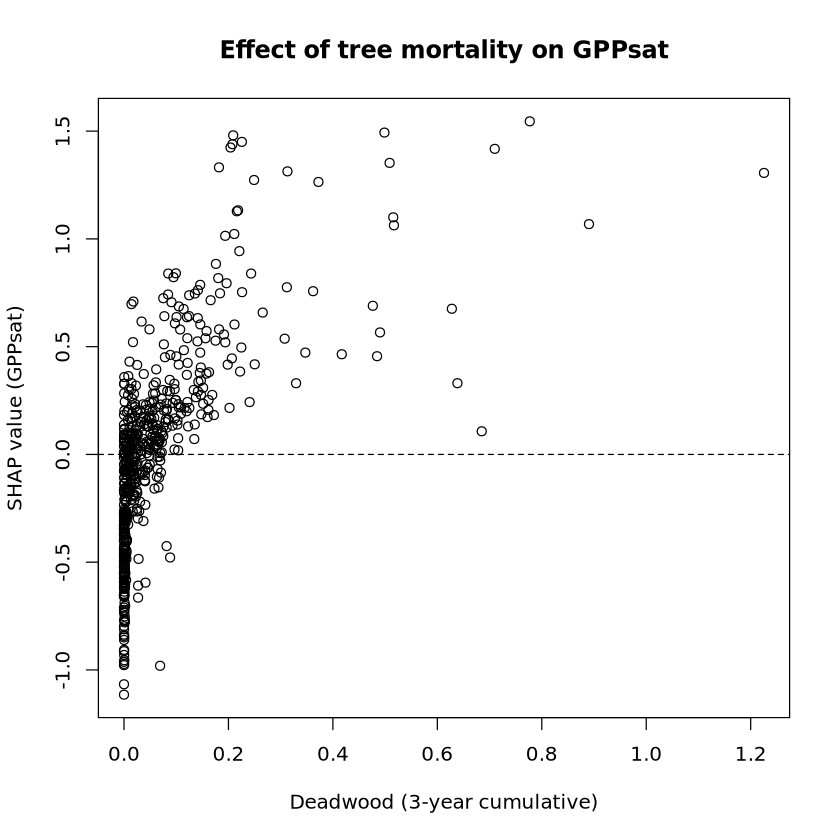

In [40]:
plot(
  X$deadwood_3yr,
  sh[, "deadwood_3yr"],
  xlab = "Deadwood (3-year cumulative)",
  ylab = "SHAP value (GPPsat)",
  main = "Effect of tree mortality on GPPsat"
)
abline(h = 0, lty = 2)

Warning message:
“Some values were outside the color scale and will be treated as NA”


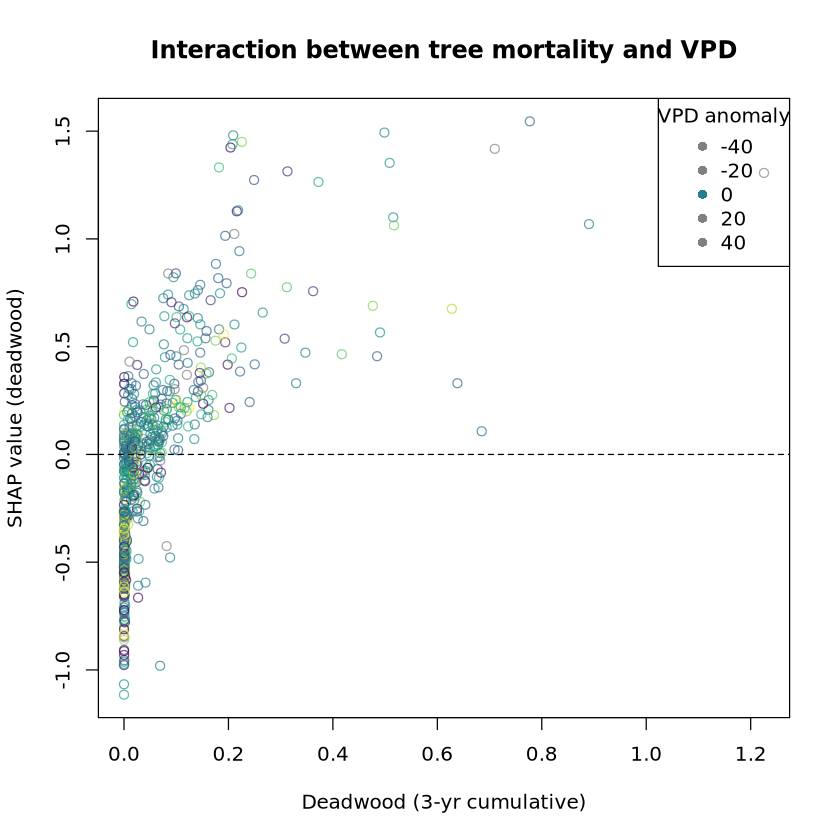

In [44]:
vpd_clip <- quantile(X$VPD_GS_hPa_anom, probs = c(0.05, 0.95), na.rm = TRUE)

col_fun <- col_numeric(
  palette = "viridis",
  domain = vpd_clip
)
legend_vals <- pretty(range(X$VPD_GS_hPa_anom, na.rm = TRUE), n = 5)
legend_cols <- col_fun(legend_vals)



plot(
  X$deadwood_3yr,
  sh[, "deadwood_3yr"],
  col = alpha(col_fun(pmin(pmax(X$VPD_GS_hPa_anom, vpd_clip[1]), vpd_clip[2])), 0.7),
  xlab = "Deadwood (3-yr cumulative)",
  ylab = "SHAP value (deadwood)",
  main = "Interaction between tree mortality and VPD"
)
abline(h = 0, lty = 2)
legend(
  "topright",
  legend = round(legend_vals, 1),
  col = legend_cols,
  pch = 16,
  title = "VPD anomaly"
)

In [45]:
y <- "GPPsat"
m <- models[[y]]$full

train_full <- train_df[
  !is.na(get(y)) &
  !is.na(deadwood_3yr) &
  !is.na(forest_mean_500m)
]

X <- train_full[, pred_full, with = FALSE]

library(fastshap)

sh <- explain(
  object = m,
  X = X,
  pred_wrapper = function(object, newdata)
    predict(object, data = newdata)$predictions,
  nsim = 100
)

In [46]:
sort(colMeans(abs(sh)), decreasing = TRUE)

SLA           LeafN_area Stem_conduit_density 
           3.4745476            2.7769873            1.5675065 
       Rooting_depth           LeafN_mass     forest_mean_500m 
           1.0825187            0.6732824            0.6319283 
     VPD_GS_hPa_anom         deadwood_3yr   SWin_mean_Wm2_anom 
           0.4178266            0.3395685            0.3342492 
    Tair_mean_C_anom            P_mm_anom 
           0.3122432            0.1794128

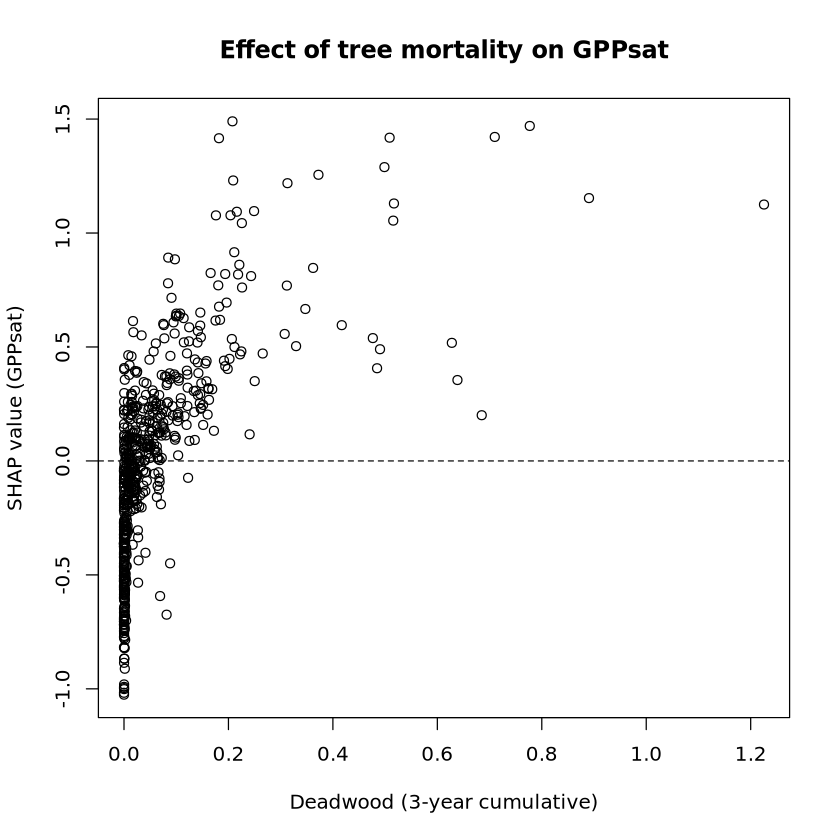

In [47]:
plot(
  X$deadwood_3yr,
  sh[, "deadwood_3yr"],
  xlab = "Deadwood (3-year cumulative)",
  ylab = "SHAP value (GPPsat)",
  main = "Effect of tree mortality on GPPsat"
)
abline(h = 0, lty = 2)

In [48]:
library(data.table)
library(ggplot2)
library(viridisLite)

In [49]:
shap_beeswarm <- function(shap_mat, X, top_n = 15, title = "SHAP summary") {
  sh_dt <- as.data.table(shap_mat)
  X_dt  <- as.data.table(X)

  # Mean |SHAP| importance → choose top features
  imp <- sort(colMeans(abs(as.matrix(sh_dt)), na.rm = TRUE), decreasing = TRUE)
  feats <- names(imp)[1:min(top_n, length(imp))]

  # Long format: one row per (obs, feature)
  sh_long <- melt(sh_dt[, ..feats], variable.name = "feature", value.name = "shap")
  x_long  <- melt(X_dt[, ..feats], variable.name = "feature", value.name = "value")

  sh_long[, value := x_long$value]

  # Order features top->bottom by importance
  sh_long[, feature := factor(feature, levels = rev(feats))]

  # Color value scaled within feature (like python shap)
  sh_long[, value_scaled := NA_real_]
  sh_long[, value_scaled := (value - quantile(value, 0.05, na.rm=TRUE)) /
                            (quantile(value, 0.95, na.rm=TRUE) - quantile(value, 0.05, na.rm=TRUE)),
          by = feature]
  sh_long[, value_scaled := pmin(pmax(value_scaled, 0), 1)]

  ggplot(sh_long, aes(x = shap, y = feature, color = value_scaled)) +
    geom_vline(xintercept = 0, linewidth = 0.4, alpha = 0.6) +
    geom_point(position = position_jitter(height = 0.18, width = 0),
               size = 1.4, alpha = 0.8) +
    scale_color_viridis_c(option = "D", direction = 1,
                          name = "Feature value",
                          labels = c("Low", "High"),
                          breaks = c(0, 1)) +
    labs(x = "SHAP value (impact on model output)", y = NULL, title = title) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major.y = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")
}

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (full model)'

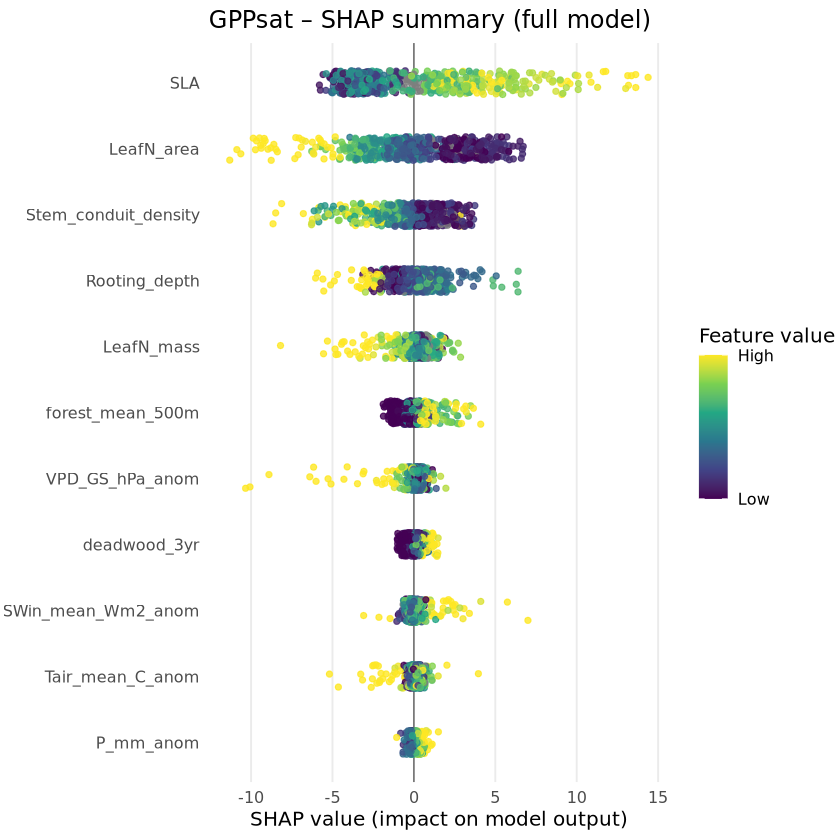

In [52]:
shap_beeswarm(
  shap_mat = sh,
  X = X,
  top_n = 12,
  title = "GPPsat – SHAP summary (full model)"
)

In [51]:
stopifnot(nrow(X) == nrow(sh))
stopifnot(all(colnames(sh) %in% names(X)))

In [53]:
ggsave("shap_beeswarm_GPPsat.png", width = 8, height = 5, dpi = 300)
ggsave("shap_beeswarm_GPPsat.pdf", width = 8, height = 5)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (full model)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$labe

In [54]:
library(fastshap)

sh <- explain(
  object = m,
  X = X,
  pred_wrapper = function(object, newdata) predict(object, data = newdata)$predictions,
  nsim = 100
)

In [55]:
library(data.table)
library(ggplot2)

shap_waterfall <- function(model, X, shap_mat, obs_id = 1, top_n = 10,
                           pred_wrapper = function(object, newdata) predict(object, data = newdata)$predictions,
                           title = "SHAP waterfall") {

  X_dt <- as.data.table(X)
  sh_dt <- as.data.table(shap_mat)

  # baseline = mean prediction on X (approx E[f(X)])
  base <- mean(pred_wrapper(model, X_dt), na.rm = TRUE)

  # prediction for the selected observation
  fx <- pred_wrapper(model, X_dt[obs_id])[1]

  # contributions for that observation
  contrib <- as.numeric(sh_dt[obs_id, ])
  names(contrib) <- names(sh_dt)

  # pick top_n by absolute contribution
  ord <- order(abs(contrib), decreasing = TRUE)
  feats <- names(contrib)[ord][1:min(top_n, length(contrib))]

  df <- data.table(
    feature = feats,
    shap = contrib[feats],
    value = as.character(unlist(X_dt[obs_id, ..feats]))
  )

  # order for plotting (largest at top)
  df[, feature_lab := paste0(value, " = ", feature)]
  df[, feature_lab := factor(feature_lab, levels = rev(feature_lab))]

  # cumulative positions (waterfall)
  df[, cum := base + cumsum(shap)]
  df[, start := shift(cum, fill = base)]
  df[, end := cum]

  df[, dir := ifelse(shap >= 0, "positive", "negative")]

  ggplot(df, aes(y = feature_lab)) +
    geom_vline(xintercept = base, linetype = 2, color = "grey60") +
    geom_segment(aes(x = start, xend = end, yend = feature_lab, color = dir),
                 linewidth = 8, lineend = "butt") +
    geom_text(aes(x = (start + end)/2, label = sprintf("%+.2f", shap)),
              color = "white", size = 4, fontface = "bold") +
    scale_color_manual(values = c(positive = "#ff0051", negative = "#0077ff"), guide = "none") +
    labs(
      title = title,
      subtitle = sprintf("E[f(X)] = %.3f   →   f(x) = %.3f   (obs_id = %d)", base, fx, obs_id),
      x = "Model output",
      y = NULL
    ) +
    theme_minimal(base_size = 13) +
    theme(panel.grid.major.y = element_blank())
}

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP waterfall (one site-year)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP waterfall (one site-year)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP waterfall (one site-year)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'E[f(X)] = 22.720   →   f(x) = 25.278   (obs_id = 25)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'E[f(X)] = 22.720   →   f(x) = 25.278   (obs_id = 25)' in 'mbcsToSbcs': dot substituted for <86>”
Warning message in grid.

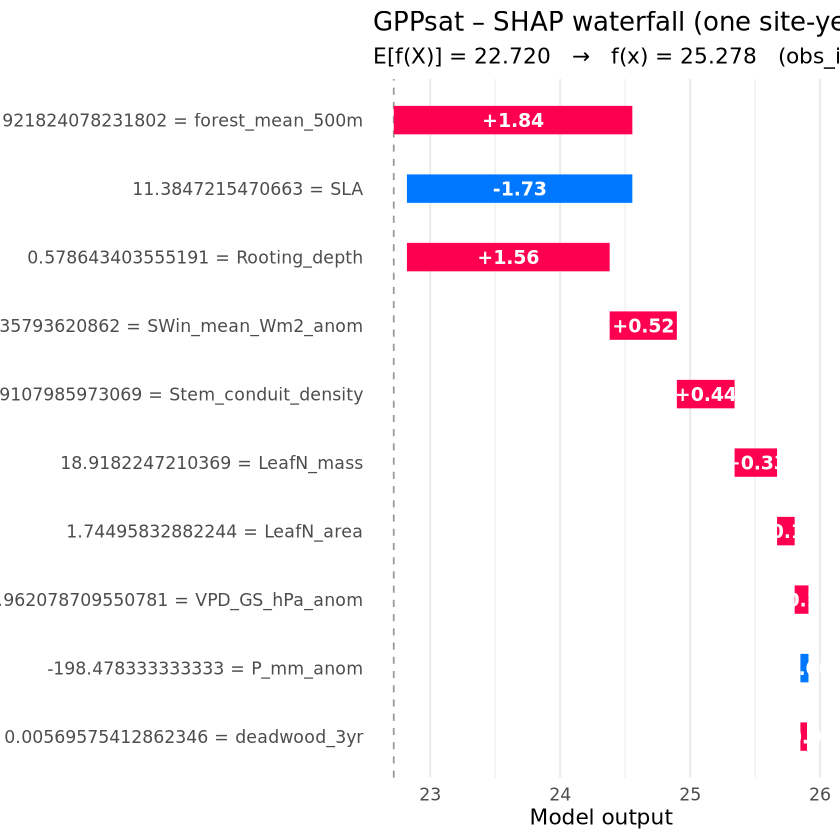

In [56]:
y <- "GPPsat"
m <- models[[y]]$full

train_full <- train_df[!is.na(get(y)) & !is.na(deadwood_3yr) & !is.na(forest_mean_500m)]
X <- train_full[, pred_full, with = FALSE]

# compute SHAP if not already
sh <- explain(m, X = X,
              pred_wrapper = function(object, newdata) predict(object, data = newdata)$predictions,
              nsim = 100)

# make waterfall for one observation (choose any row index)
shap_waterfall(model = m, X = X, shap_mat = sh, obs_id = 25, top_n = 10,
               title = "GPPsat – SHAP waterfall (one site-year)")

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP waterfall (max deadwood case)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP waterfall (max deadwood case)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP waterfall (max deadwood case)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'E[f(X)] = 22.720   →   f(x) = 33.990   (obs_id = 16)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'E[f(X)] = 22.720   →   f(x) = 33.990   (obs_id = 16)' in 'mbcsToSbcs': dot substituted for <86>”
Warning mess

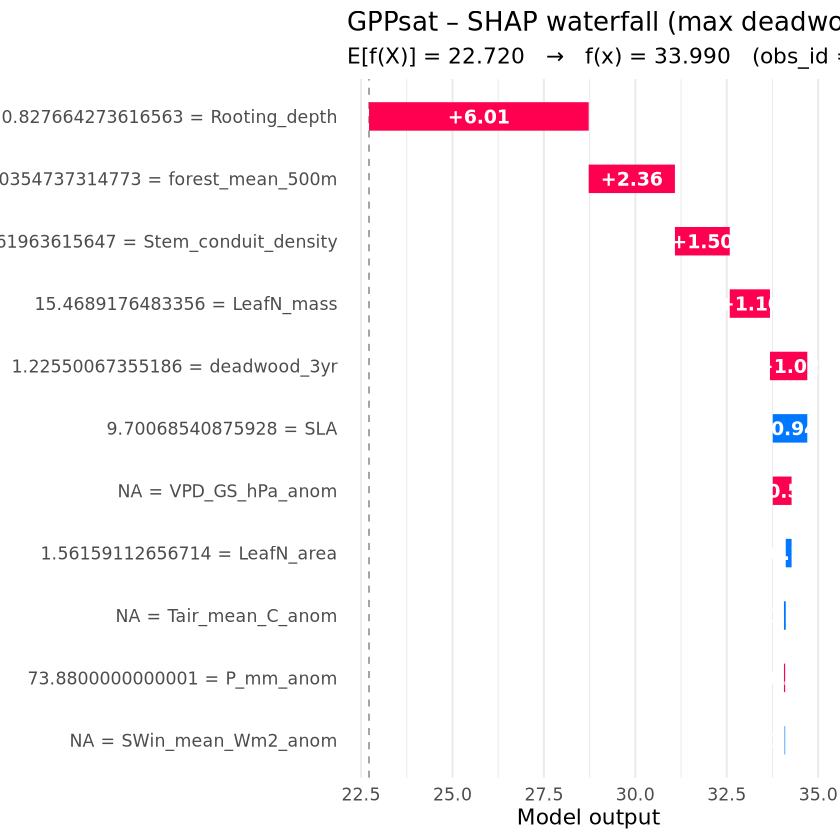

In [57]:
obs_id <- which.max(X$deadwood_3yr)
shap_waterfall(m, X, sh, obs_id = obs_id, top_n = 12,
               title = "GPPsat – SHAP waterfall (max deadwood case)")

In [58]:
library(data.table)

# dt = your modeling table
# final_df contains IGBP
igbp_map <- unique(final_df[, .(SITE_ID, IGBP)])
dt <- merge(dt, igbp_map, by = "SITE_ID", all.x = TRUE)

# quick check
table(is.na(dt$IGBP))


FALSE 
 2311 

In [59]:
library(fastshap)

y <- "GPPsat"
m <- models[[y]]$full

train_full <- train_df[
  !is.na(get(y)) & !is.na(deadwood_3yr) & !is.na(forest_mean_500m)
]

# IMPORTANT: carry IGBP into the same row set
train_full <- merge(train_full, igbp_map, by = "SITE_ID", all.x = TRUE)

X <- train_full[, pred_full, with = FALSE]

sh <- explain(
  object = m,
  X = X,
  pred_wrapper = function(object, newdata) predict(object, data = newdata)$predictions,
  nsim = 100
)

In [60]:
library(ggplot2)
library(viridisLite)

shap_beeswarm_group <- function(shap_mat, X, title, top_n = 12, xlim_fixed = NULL) {
  sh_dt <- as.data.table(shap_mat)
  X_dt  <- as.data.table(X)

  # choose top features by mean |SHAP| within the subset
  imp <- sort(colMeans(abs(as.matrix(sh_dt)), na.rm = TRUE), decreasing = TRUE)
  feats <- names(imp)[1:min(top_n, length(imp))]

  sh_long <- melt(sh_dt[, ..feats], variable.name = "feature", value.name = "shap")
  x_long  <- melt(X_dt[, ..feats], variable.name = "feature", value.name = "value")
  sh_long[, value := x_long$value]

  # feature order
  sh_long[, feature := factor(feature, levels = rev(feats))]

  # scale feature value within feature (5–95% clipping)
  sh_long[, value_scaled := {
    lo <- quantile(value, 0.05, na.rm = TRUE)
    hi <- quantile(value, 0.95, na.rm = TRUE)
    v  <- (value - lo) / (hi - lo)
    pmin(pmax(v, 0), 1)
  }, by = feature]

  p <- ggplot(sh_long, aes(x = shap, y = feature, color = value_scaled)) +
    geom_vline(xintercept = 0, linewidth = 0.4, color = "grey50") +
    geom_point(position = position_jitter(height = 0.18, width = 0),
               size = 1.2, alpha = 0.85) +
    scale_color_viridis_c(option = "D", name = "Feature value",
                          breaks = c(0, 1), labels = c("Low", "High")) +
    labs(title = title, x = "SHAP value (impact on model output)", y = NULL) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major.y = element_blank(),
          panel.grid.minor = element_blank())

  if (!is.null(xlim_fixed)) p <- p + coord_cartesian(xlim = xlim_fixed)
  p
}

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”

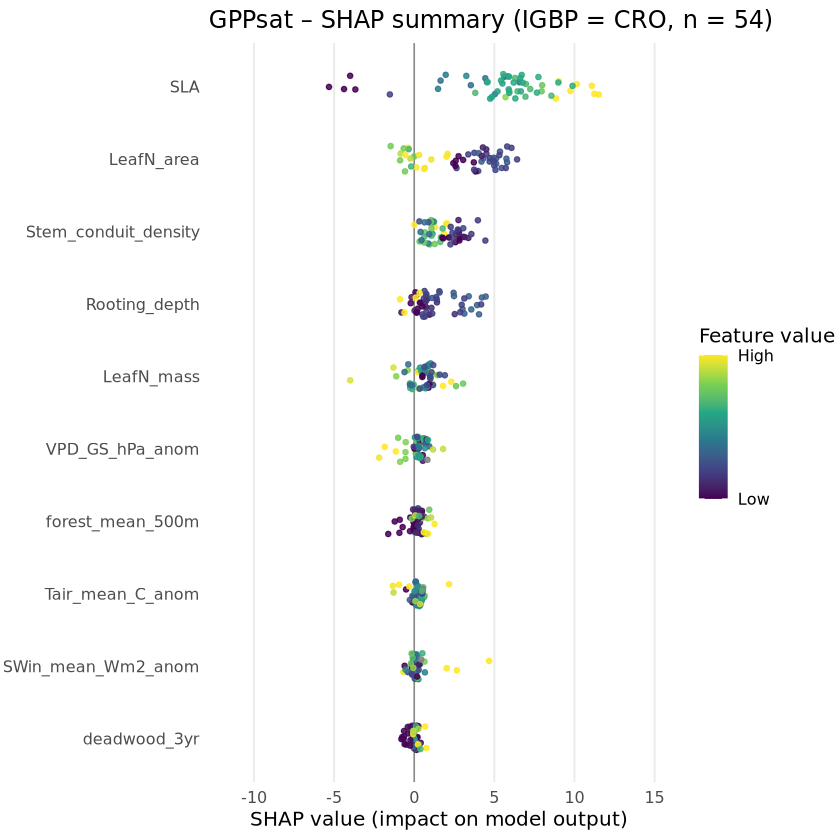

In [61]:
# global x-limits from all rows used in SHAP
xlim_fixed <- range(as.matrix(sh), na.rm = TRUE)
xlim_fixed <- c(min(xlim_fixed), max(xlim_fixed))

igbps <- sort(unique(na.omit(train_full$IGBP)))

plots <- list()

for (g in igbps) {
  idx <- which(train_full$IGBP == g)

  # skip tiny groups (optional)
  if (length(idx) < 30) next

  plots[[g]] <- shap_beeswarm_group(
    shap_mat = sh[idx, , drop = FALSE],
    X = X[idx, ],
    title = paste0("GPPsat – SHAP summary (IGBP = ", g, ", n = ", length(idx), ")"),
    top_n = 10,
    xlim_fixed = xlim_fixed
  )
}

# Show one:
plots[[1]]

In [62]:
dir.create("shap_plots_by_IGBP", showWarnings = FALSE)

for (g in names(plots)) {
  ggsave(
    filename = file.path("shap_plots_by_IGBP", paste0("beeswarm_GPPsat_IGBP_", g, ".png")),
    plot = plots[[g]],
    width = 7, height = 4.5, dpi = 300
  )
}

In [63]:
# pick a fixed feature set (global top features)
global_imp <- sort(colMeans(abs(as.matrix(sh)), na.rm = TRUE), decreasing = TRUE)
feats_global <- names(global_imp)[1:12]

imp_by_igbp <- rbindlist(lapply(igbps, function(g) {
  idx <- which(train_full$IGBP == g)
  if (length(idx) < 30) return(NULL)
  vals <- colMeans(abs(as.matrix(sh[idx, feats_global, drop = FALSE])), na.rm = TRUE)
  data.table(IGBP = g, feature = names(vals), mean_abs_shap = as.numeric(vals))
}))

ggplot(imp_by_igbp, aes(x = feature, y = IGBP, fill = mean_abs_shap)) +
  geom_tile() +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Mean |SHAP| by IGBP (GPPsat full model)", x = NULL, y = NULL)

ERROR: Error in sh[idx, feats_global, drop = FALSE]: subscript out of bounds


re-run for NEPmax

In [ ]:
y <- "NEPmax"  # or ETmax, uWUE
m <- models[[y]]$full


train_full <- train_df[
  !is.na(get(y)) & !is.na(deadwood_3yr) & !is.na(forest_mean_500m)
]

# IMPORTANT: carry IGBP into the same row set
train_full <- merge(train_full, igbp_map, by = "SITE_ID", all.x = TRUE)

X <- train_full[, pred_full, with = FALSE]

sh <- explain(
  object = m,
  X = X,
  pred_wrapper = function(object, newdata) predict(object, data = newdata)$predictions,
  nsim = 100
)

In [ ]:
library(ggplot2)
library(viridisLite)

shap_beeswarm_group <- function(shap_mat, X, title, top_n = 12, xlim_fixed = NULL) {
  sh_dt <- as.data.table(shap_mat)
  X_dt  <- as.data.table(X)

  # choose top features by mean |SHAP| within the subset
  imp <- sort(colMeans(abs(as.matrix(sh_dt)), na.rm = TRUE), decreasing = TRUE)
  feats <- names(imp)[1:min(top_n, length(imp))]

  sh_long <- melt(sh_dt[, ..feats], variable.name = "feature", value.name = "shap")
  x_long  <- melt(X_dt[, ..feats], variable.name = "feature", value.name = "value")
  sh_long[, value := x_long$value]

  # feature order
  sh_long[, feature := factor(feature, levels = rev(feats))]

  # scale feature value within feature (5–95% clipping)
  sh_long[, value_scaled := {
    lo <- quantile(value, 0.05, na.rm = TRUE)
    hi <- quantile(value, 0.95, na.rm = TRUE)
    v  <- (value - lo) / (hi - lo)
    pmin(pmax(v, 0), 1)
  }, by = feature]

  p <- ggplot(sh_long, aes(x = shap, y = feature, color = value_scaled)) +
    geom_vline(xintercept = 0, linewidth = 0.4, color = "grey50") +
    geom_point(position = position_jitter(height = 0.18, width = 0),
               size = 1.2, alpha = 0.85) +
    scale_color_viridis_c(option = "D", name = "Feature value",
                          breaks = c(0, 1), labels = c("Low", "High")) +
    labs(title = title, x = "SHAP value (impact on model output)", y = NULL) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major.y = element_blank(),
          panel.grid.minor = element_blank())

  if (!is.null(xlim_fixed)) p <- p + coord_cartesian(xlim = xlim_fixed)
  p
}